## Import Packages

In [1]:
import os
import yaml
import math
import pandas as pd
import numpy as np
import scanpy as sc
import scipy.io
import humanfriendly

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

## Parameters

In [3]:
# this cell is tagged `parameters` and will be overridden by papermill
sample_name = "1973_HD1915_7xNK_FB_HTO"
path_h5ad = "/test/hashtag/1973_HD1915_7xNK_FB_HTO.h5ad"
path_report = "/test/hashtag/run_report.yaml"
path_read_mtx = "/test/hashtag/reads/matrix.mtx.gz"
path_outdir = "/test/hashtag"

## Run Report

In [4]:
!cat $path_report

Date: 2021-07-26
Running time: 5.0 minutes, 29.7 seconds
CITE-seq-Count Version: 1.4.3
Reads processed: 10711133
Percentage mapped: 95
Percentage unmapped: 5
Uncorrected cells: 1
Correction:
	Cell barcodes collapsing threshold: 1
	Cell barcodes corrected: 57585
	UMI collapsing threshold: 1
	UMIs corrected: 21000
Run parameters:
	Read1_filename: /tmp/scratch/dp-lab-gwf-core/cromwell-execution/Hashtag/e310f49b-44df-4ed0-a723-738a4ff06480/call-Preprocess/Preprocess/95c18bc7-7aca-4ba0-ab18-7cb3f2c8f0db/call-TrimR1/cacheCopy/R1.fastq.gz
	Read2_filename: /tmp/scratch/dp-lab-gwf-core/cromwell-execution/Hashtag/e310f49b-44df-4ed0-a723-738a4ff06480/call-Preprocess/Preprocess/95c18bc7-7aca-4ba0-ab18-7cb3f2c8f0db/call-TrimR2/cacheCopy/R2.fastq.gz
	Cell barcode:
		First position: 1
		Last position: 16
	UMI barcode:
		First position: 17
		Last position: 28
	Expected cells: 0
	Tags max errors: 2
	Start trim: 10


In [ ]:
with open(path_report, "rt") as fin:
    # report file contains tabs
    # run_report = yaml.load(fin, Loader=yaml.FullLoader)
    run_report = fin.read().replace("\t", "  ")
    run_report = yaml.load(run_report, Loader=yaml.FullLoader)

In [6]:
# num of reads processed
humanfriendly.format_number(run_report["Reads processed"])

'10,711,133'

In [7]:
# percentage mapped
run_report["Percentage mapped"]

95

## Load AnnData

In [8]:
adata = sc.read_h5ad(path_h5ad)

In [9]:
adata

AnnData object with n_obs × n_vars = 10957 × 7
    obs: 'unmapped', 'barcode_sequence', 'hash_id'
    var: 'feature_name'

In [10]:
adata.obs

,unmapped,barcode_sequence,hash_id
227303201131438,27,CTGTGAACATCAGCGC,Doublet
191766864546027,16,GTACAACTCGCAATGT,A0252
227434332055453,7,CTGGACGCAAACTCTG,A0256
133921842280299,14,TCTACATTCGATTGGT,A0255
165239984667435,21,AGAAATGCAGGTGAGT,A0257
...,...,...,...
197281467784107,24,GACCCAGTCTGGGCGT,A0251
205861516597556,13,GCCTGTTCAATGAACA,A0251
196576840146219,30,GAGAAATAGCAGCAGT,Doublet
162072265964956,17,AACCTGATCGCTCCTA,A0257


In [11]:
adata.var

,feature_name
A0251-GTCAACTCTTTAGCG,CD56brightA+C-
A0252-TGATGGCCTATTGGG,CD56brightA+C+
A0253-TTCCGCCTCTCTTTG,CD56dimA+C+
A0254-AGTAAGTTCAGCGTA,CD56dimA+C-
A0255-AAGTATCGTTTCGCA,CD56dimA-C+NKp30hi
A0256-GGTTGCCAGATGTCA,CD56dimA-C+NKp30-
A0257-TGTCTTTCCTGCCAG,CD56dimA-C-


In [12]:
adata.to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
227303201131438,0,408,329,9,2,0,1
191766864546027,0,533,1,3,1,1,0
227434332055453,0,0,0,1,0,235,1
133921842280299,0,0,1,1,490,0,0
165239984667435,1,1,2,3,0,1,607
...,...,...,...,...,...,...,...
197281467784107,423,0,2,5,0,2,1
205861516597556,324,4,2,4,0,0,0
196576840146219,0,572,2,50,2,1,0
162072265964956,1,1,0,2,0,1,472


## Load Read Counts

In [13]:
mtx = scipy.io.mmread(path_read_mtx)

In [14]:
adata.layers["reads"] = mtx.T.tocsr()[:, :-1]

In [15]:
adata.obs["unmapped_reads"] = mtx.T.toarray()[:, -1]

In [16]:
adata.obs

,unmapped,barcode_sequence,hash_id,unmapped_reads
227303201131438,27,CTGTGAACATCAGCGC,Doublet,36
191766864546027,16,GTACAACTCGCAATGT,A0252,21
227434332055453,7,CTGGACGCAAACTCTG,A0256,8
133921842280299,14,TCTACATTCGATTGGT,A0255,15
165239984667435,21,AGAAATGCAGGTGAGT,A0257,30
...,...,...,...,...
197281467784107,24,GACCCAGTCTGGGCGT,A0251,28
205861516597556,13,GCCTGTTCAATGAACA,A0251,13
196576840146219,30,GAGAAATAGCAGCAGT,Doublet,37
162072265964956,17,AACCTGATCGCTCCTA,A0257,20


## Classification

In [17]:
adata.obs

,unmapped,barcode_sequence,hash_id,unmapped_reads
227303201131438,27,CTGTGAACATCAGCGC,Doublet,36
191766864546027,16,GTACAACTCGCAATGT,A0252,21
227434332055453,7,CTGGACGCAAACTCTG,A0256,8
133921842280299,14,TCTACATTCGATTGGT,A0255,15
165239984667435,21,AGAAATGCAGGTGAGT,A0257,30
...,...,...,...,...
197281467784107,24,GACCCAGTCTGGGCGT,A0251,28
205861516597556,13,GCCTGTTCAATGAACA,A0251,13
196576840146219,30,GAGAAATAGCAGCAGT,Doublet,37
162072265964956,17,AACCTGATCGCTCCTA,A0257,20


### Results

In [18]:
df_stats = adata.obs.groupby("hash_id").size()
df_stats

hash_id
A0251      1638
A0252      1135
A0253      2742
A0254      1007
A0255      1244
A0256      1295
A0257       874
Doublet    1022
dtype: int64

In [19]:
df_stats.sum()

10957

In [20]:
# sum excluding doublets
df_stats[ df_stats.index != "Doublet" ].sum()

9935

### Pie Chart

In [21]:
labels = [label if label != "Doublet" else "Doublet/Negative" for label in df_stats.index]
labels

['A0251',
 'A0252',
 'A0253',
 'A0254',
 'A0255',
 'A0256',
 'A0257',
 'Doublet/Negative']

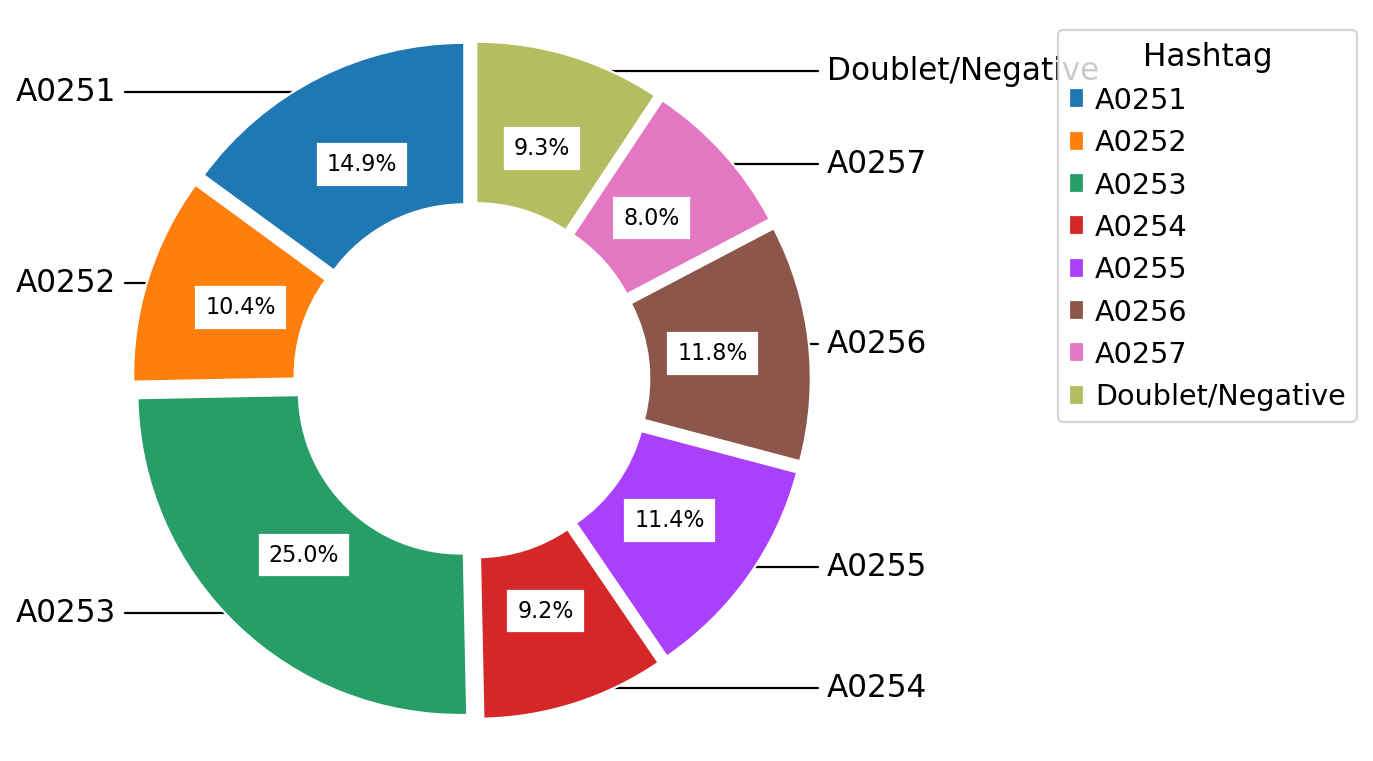

In [ ]:
fig = plt.figure(figsize=(6,6), facecolor="white")
ax = fig.add_subplot(111)

def func_autopct(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:,d})".format(pct, absolute)

cmap = plt.get_cmap("tab20c")

wedges, _, autotexts = ax.pie(
    df_stats,
    explode=[0.05] * len(df_stats),
    wedgeprops=dict(width=0.5, edgecolor='w'),
    autopct='%1.1f%%',
    pctdistance=0.7,
    shadow=False,
    startangle=90,
    rotatelabels=True
)

kw = dict(arrowprops=dict(arrowstyle="-"), zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1) / 2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(
        labels[i], xy=(x, y), xytext=(1.1 * np.sign(x), y),
        horizontalalignment=horizontalalignment, **kw
    )

for i, autotext in enumerate(autotexts):
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_rotation(0)
    autotext.set_backgroundcolor("white")

ax.axis('equal')
ax.legend(
    wedges,
    labels,
    title="Hashtag",
    bbox_to_anchor=(1.2, 0.0, 0.5, 1)
)

plt.show()

### Distribution

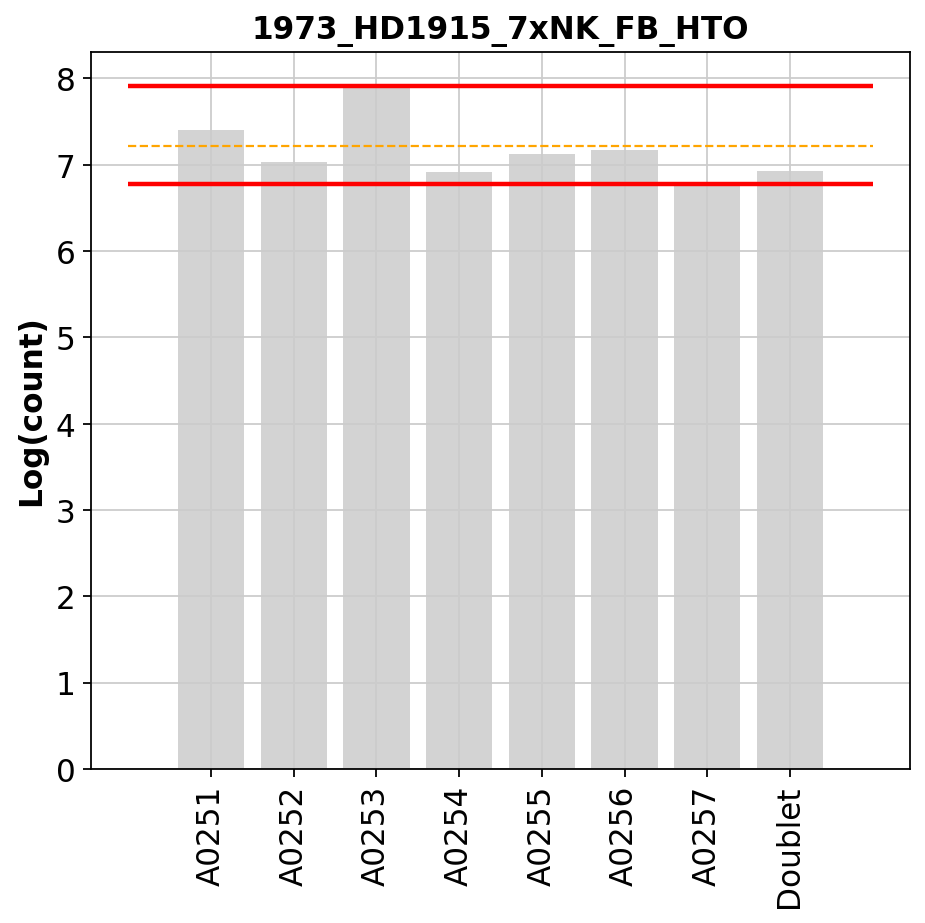

In [ ]:
fig = plt.figure(figsize=(6,6), facecolor="white")
ax = fig.add_subplot(111)

ax.bar(df_stats.index, np.log(list(df_stats.values)), color="lightgray")

ax.set_ylabel("Log(count)", fontweight="bold")
ax.set_title(sample_name, fontsize=14, fontweight="heavy")
ax.tick_params(axis="x", rotation=90)

if len(df_stats) != 0:
    num_hashtags = len(df_stats.values)
    ax.hlines(y=np.log(max(df_stats.values)), xmin=-1, xmax=num_hashtags, colors='red', linestyles='-', lw=2)
    ax.hlines(y=np.log(min(df_stats.values)), xmin=-1, xmax=num_hashtags, colors='red', linestyles='-', lw=2)
    ax.hlines(y=np.log(np.mean(list(df_stats.values))), xmin=-1, xmax=num_hashtags, colors='orange', linestyles='--', lw=1)

plt.tight_layout()

plt.show()

## Read Counts

In [24]:
adata.to_df(layer="reads")

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
227303201131438,0,499,407,11,3,0,1
191766864546027,0,642,1,3,1,1,0
227434332055453,0,0,0,1,0,290,2
133921842280299,0,0,2,1,592,0,0
165239984667435,1,1,2,3,0,3,710
...,...,...,...,...,...,...,...
197281467784107,525,0,3,6,0,2,1
205861516597556,374,5,2,4,0,0,0
196576840146219,0,705,2,63,2,1,0
162072265964956,1,1,0,2,0,1,587


### Matrix vs. Run Report

Note that unmapped reads are excluded.

In [25]:
adata.layers["reads"].sum()

8234964

In [26]:
adata.layers["reads"].sum(), run_report["Reads processed"]

(8234964, 10711133)

In [27]:
adata.layers["reads"].sum() / run_report["Reads processed"] * 100

76.88228686918555

### Total Reads per Hashtag

In [28]:
adata.var["total_reads"] = adata.layers["reads"].sum(axis=0).A1

In [29]:
adata.var["total_reads"]

A0251-GTCAACTCTTTAGCG     846398
A0252-TGATGGCCTATTGGG     880547
A0253-TTCCGCCTCTCTTTG    1677480
A0254-AGTAAGTTCAGCGTA    1246014
A0255-AAGTATCGTTTCGCA    1199948
A0256-GGTTGCCAGATGTCA    1534074
A0257-TGTCTTTCCTGCCAG     850503
Name: total_reads, dtype: int64

### Total Reads per Celluar Barcode

In [30]:
adata.obs["total_reads"] = adata.layers["reads"].sum(axis=1).A1

In [31]:
adata.obs["total_reads"]

227303201131438    921
191766864546027    648
227434332055453    293
133921842280299    595
165239984667435    720
                  ... 
197281467784107    537
205861516597556    385
196576840146219    773
162072265964956    592
122490813798755    315
Name: total_reads, Length: 10957, dtype: int64

### Zero Rows

In [32]:
np.count_nonzero(adata.obs["total_reads"] == 0)

9

In [33]:
np.count_nonzero(adata.obs["total_reads"] == 0) / adata.shape[0]

0.0008213927169845761

### First Hashtag

In [34]:
# define a variable called "hashtags" contains all the hashtag names except "Doublet" and "Negative"
hashtags = sorted(list(set(adata.obs["hash_id"].unique()) - set(["Doublet", "Negative"])))
hashtags

['A0251', 'A0252', 'A0253', 'A0254', 'A0255', 'A0256', 'A0257']

In [35]:
# pick the first hashtag
first_hashtag = hashtags[0] if len(hashtags) > 0 else None
first_hashtag

'A0251'

In [36]:
adata.to_df(layer="reads")[adata.obs["hash_id"] == first_hashtag].sort_values(adata.var.index[0], ascending=False)

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
236176853592492,1977,3,5,1,0,0,2
235550861908379,1748,5,5,11,3,0,1
160361944378787,1449,2,1,6,1,2,0
135504967154595,1384,5,2,36,1,0,1
236176853068198,1278,2,3,8,0,3,2
...,...,...,...,...,...,...,...
191706615102835,65,1,0,7,0,0,0
126347801152436,63,0,0,0,0,0,0
191646632368931,49,0,0,0,1,0,0
204908283221805,19,0,1,3,0,0,0


### Overall Stats

In [37]:
adata.to_df(layer="reads").sum(axis=1).describe()

count    10957.000000
mean       751.571050
std        630.473517
min          0.000000
25%        452.000000
50%        646.000000
75%        913.000000
max      22809.000000
dtype: float64

### 95 Percentile

In [38]:
percentile_95 = adata.obs["total_reads"].describe(percentiles=[0.95])["95%"]
percentile_95

1510.199999999999

In [39]:
adata.to_df(layer="reads")[ adata.obs["total_reads"] > percentile_95 ]

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
126150233472412,3,0,2,1623,6,1100,9
196046410958707,0,3,1,1772,3,0,0
241097665080116,1,0,2,11,1,1913,12
235067397257646,504,0,507,877,2,0,0
231754888570724,2,2,1606,3,0,0,0
...,...,...,...,...,...,...,...
157623887514540,1,6,1,2,7,2095,13
227915503192350,3,3,2,4,5,1716,11
135632493075700,0,7,6,2,1714,0,0
236718690879774,1,2,539,0,3,1325,6


In [40]:
adata.to_df(layer="reads")[ adata.obs["total_reads"] > percentile_95 ].sample(5, random_state=0)

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
204359588830124,0,1,8,12,1708,3,0
129593856940469,0,3,1743,15,3,1,1
126767500048245,2,0,4,0,5,1644,13
191141961426716,0,594,0,571,586,1,0
135081900300715,384,0,0,1,0,1229,6


In [41]:
adata.to_df(layer="reads")[ adata.obs["total_reads"] > percentile_95 ].sample(5, random_state=0).sum(axis=1)

204359588830124    1732
129593856940469    1766
126767500048245    1668
191141961426716    1752
135081900300715    1620
dtype: int64

### Histogram (sum of reads across hashtags)

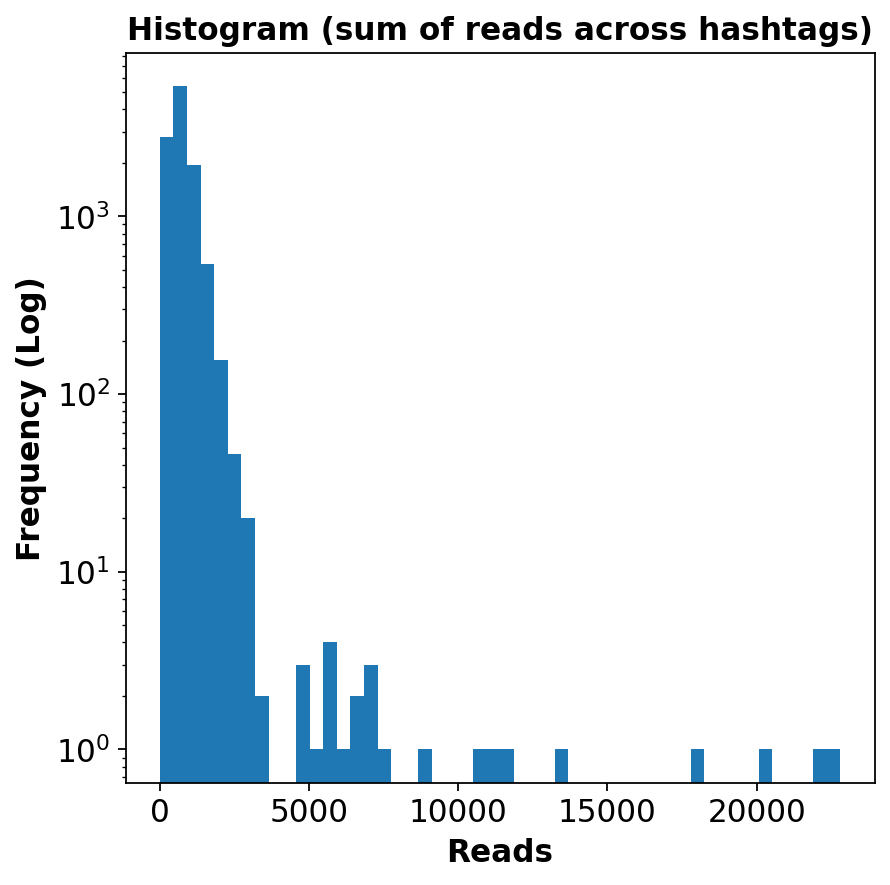

In [42]:
fig, ax = plt.subplots(figsize=(6,6), facecolor="white")

ax.hist(adata.obs["total_reads"].sort_values(ascending=False), bins=50)

ax.set_xlabel("Reads", fontweight="bold")
ax.set_ylabel("Frequency (Log)", fontweight="bold")
ax.set_title("Histogram (sum of reads across hashtags)", fontweight="bold")
ax.grid(b=False)

plt.yscale("log")
plt.show()

### Histogram (sum of reads per hashtag)

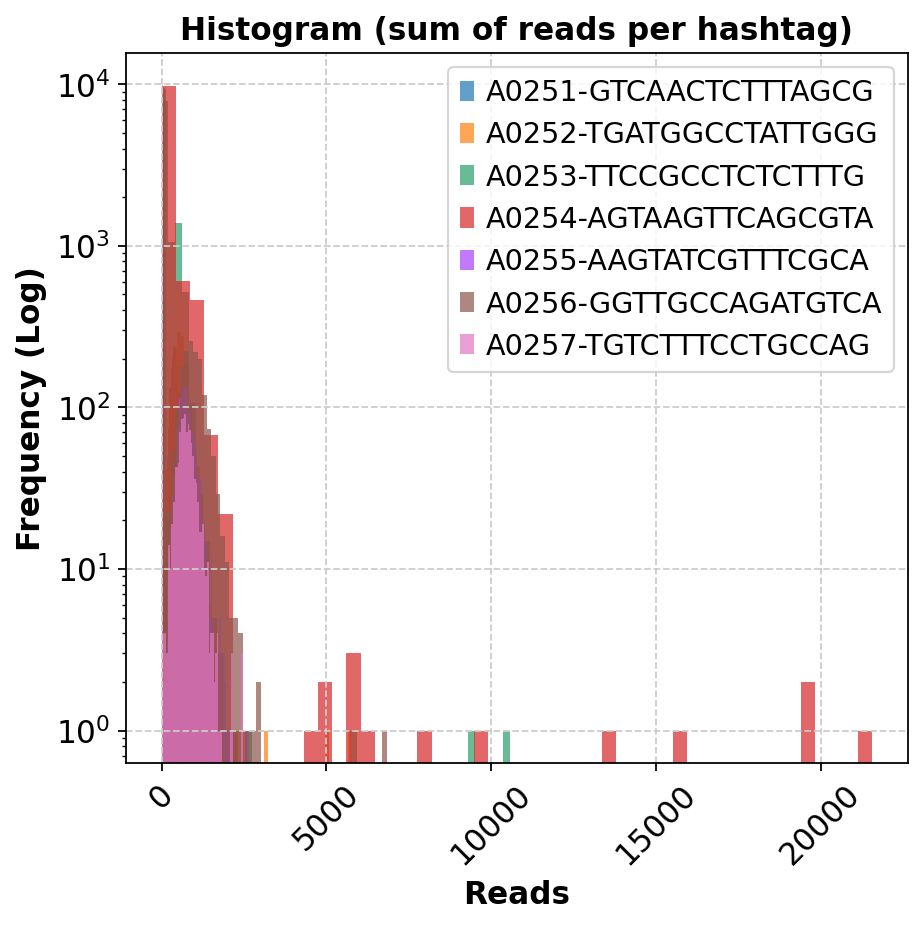

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

for idx, col in enumerate(adata.var_names):

    df_tmp = np.sort(adata.layers["reads"][:, idx].A.ravel())[::-1]

    ax.hist(df_tmp, bins=50, alpha=0.7, label=col)

ax.set_xlabel("Reads", fontweight="bold")
ax.set_ylabel("Frequency (Log)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.set_title("Histogram (sum of reads per hashtag)", fontweight="bold")
ax.grid(b=True, linestyle="--")
ax.legend()

plt.yscale("log")
plt.tight_layout()
plt.show()

### Unmapped

In [44]:
adata.obs["unmapped_reads"].sort_values(ascending=False)

126268612721964    818
231754935421741    783
120703436111133    725
226960793098029    638
195554937355164    622
                  ... 
125238492219116      0
226212233211229      0
125238491662763      0
122490786564902      0
126682835925812      0
Name: unmapped_reads, Length: 10957, dtype: int64

In [45]:
adata.obs["unmapped_reads"].sum()

311426

### Total vs. Unmapped Reads

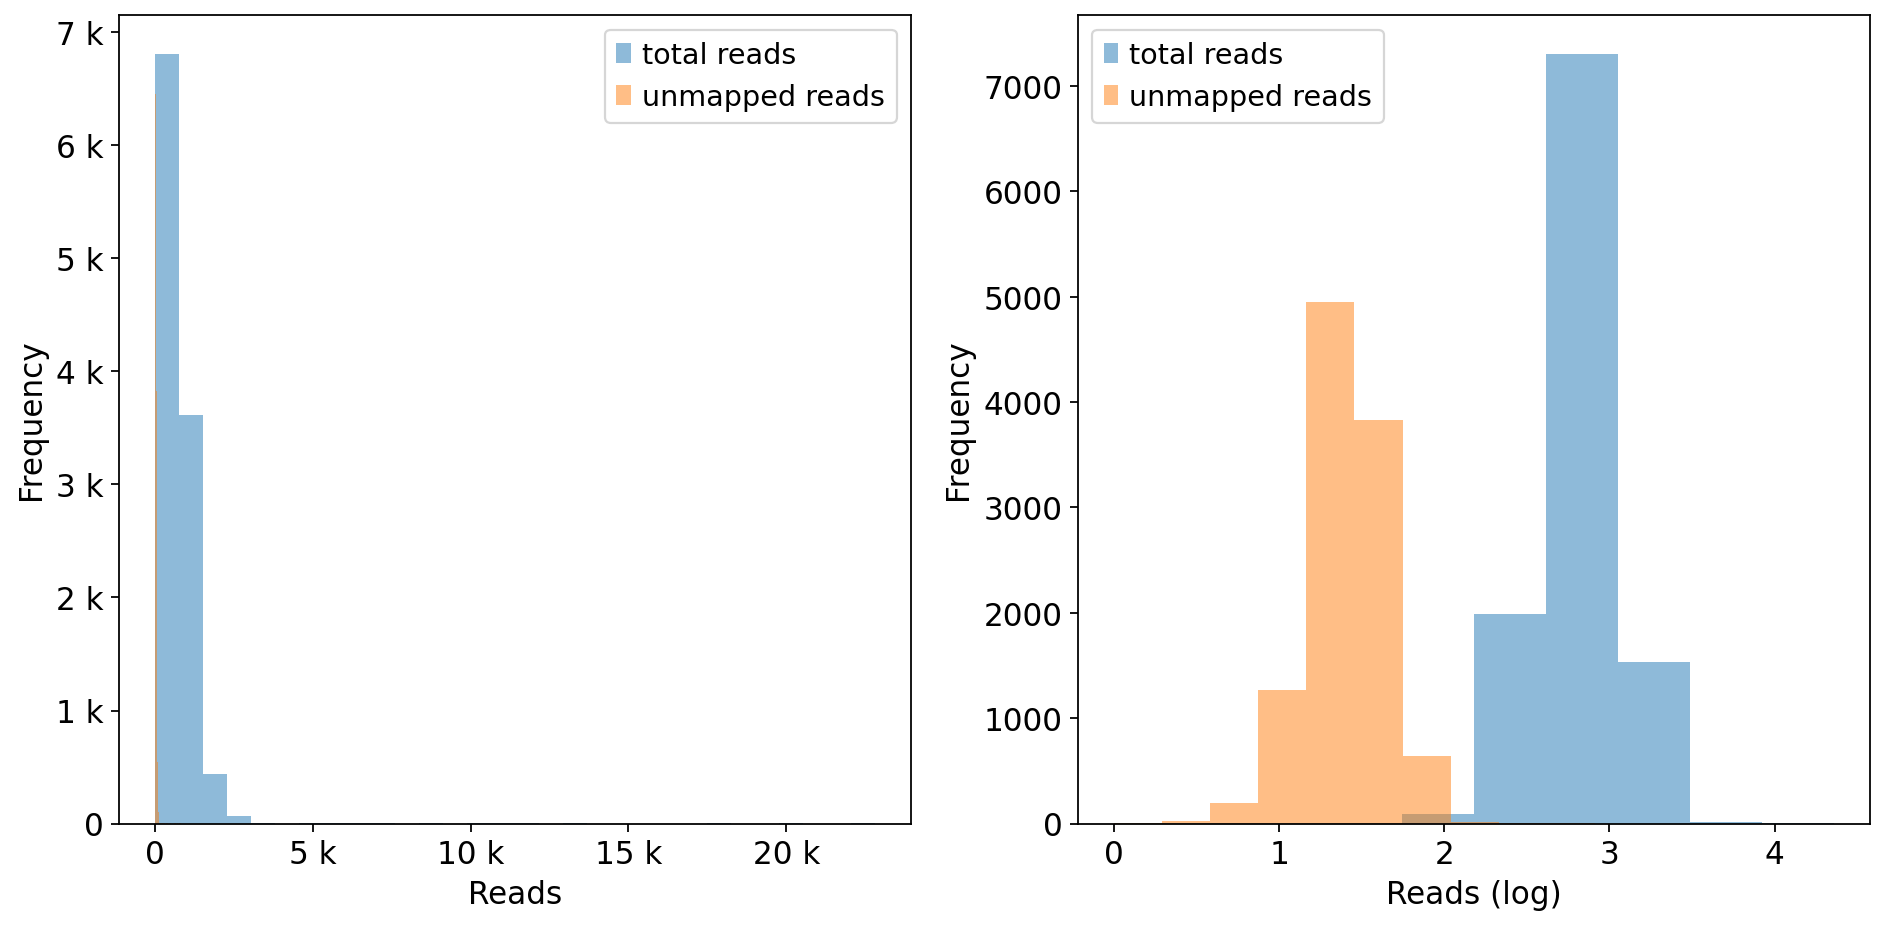

In [46]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6), facecolor="white")
ax = np.ravel(ax)

ax[0].hist(adata.obs["total_reads"], bins=30, label="total reads", alpha=0.5)
ax[0].hist(adata.obs["unmapped_reads"], bins=30, label="unmapped reads", alpha=0.5)

ax[0].set_xlabel("Reads")
ax[0].set_ylabel("Frequency")
ax[0].xaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
ax[0].yaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
ax[0].grid(b=False)
ax[0].legend()

ax[1].hist(np.log10(adata.obs["total_reads"] + 1), label="total reads", alpha=0.5)
ax[1].hist(np.log10(adata.obs["unmapped_reads"] + 1), label="unmapped reads", alpha=0.5)

ax[1].set_xlabel("Reads (log)")
ax[1].set_ylabel("Frequency")
ax[1].grid(b=False)
ax[1].legend()

plt.tight_layout()
plt.show()

## UMI Counts

In [47]:
adata.to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
227303201131438,0,408,329,9,2,0,1
191766864546027,0,533,1,3,1,1,0
227434332055453,0,0,0,1,0,235,1
133921842280299,0,0,1,1,490,0,0
165239984667435,1,1,2,3,0,1,607
...,...,...,...,...,...,...,...
197281467784107,423,0,2,5,0,2,1
205861516597556,324,4,2,4,0,0,0
196576840146219,0,572,2,50,2,1,0
162072265964956,1,1,0,2,0,1,472


In [48]:
# total UMIs per cell barcode
adata.obs["total_umis"] = adata.X.sum(axis=1).A1

### Histogram (sum of UMIs across hashtag)

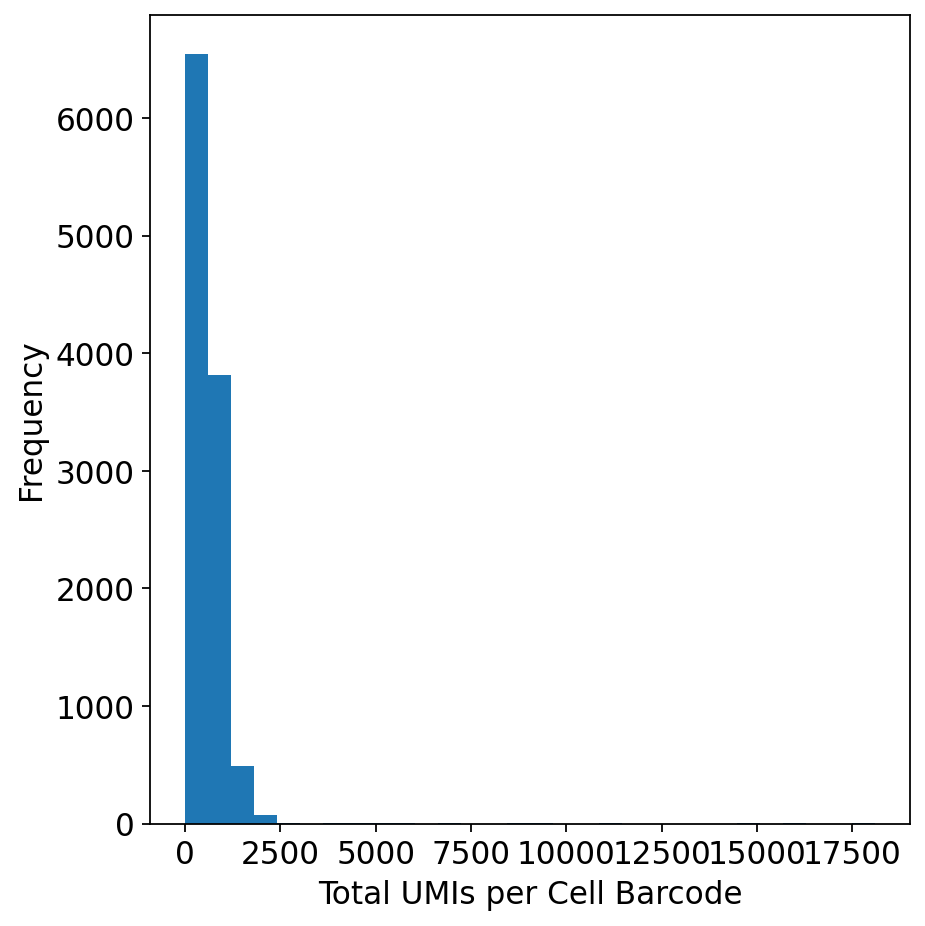

In [49]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

ax.hist(adata.obs["total_umis"], bins=30)
ax.set_xlabel("Total UMIs per Cell Barcode")
ax.set_ylabel("Frequency")
ax.grid(b=False)

plt.tight_layout()
plt.show()

In [50]:
adata.to_df().describe()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
count,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000
mean,63.323994,65.425573,125.839828,93.008762,89.748745,114.346628,63.653372
std,145.966145,190.989659,239.422077,415.659342,239.239001,304.011884,204.819884
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,2.000000,4.000000,1.000000,1.000000,0.000000
75%,2.000000,3.000000,274.000000,6.000000,2.000000,2.000000,2.000000
max,1610.000000,4642.000000,8536.000000,17070.000000,2170.000000,5546.000000,2004.000000


## Reads per UMI

### Calculate

In [51]:
# reads divided by UMI, replace NaN with zero
reads_per_umi = np.nan_to_num(adata.layers["reads"] / adata.X)

In [52]:
pd.DataFrame(reads_per_umi)

,0,1,2,3,4,5,6
0,0.000000,1.223039,1.237082,1.222222,1.500000,0.000000,1.000000
1,0.000000,1.204503,1.000000,1.000000,1.000000,1.000000,0.000000
2,0.000000,0.000000,0.000000,1.000000,0.000000,1.234043,2.000000
3,0.000000,0.000000,2.000000,1.000000,1.208163,0.000000,0.000000
4,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,1.169687
...,...,...,...,...,...,...,...
10952,1.241135,0.000000,1.500000,1.200000,0.000000,1.000000,1.000000
10953,1.154321,1.250000,1.000000,1.000000,0.000000,0.000000,0.000000
10954,0.000000,1.232517,1.000000,1.260000,1.000000,1.000000,0.000000
10955,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.243644


In [53]:
adata.obs["total_umis"].sum()

6742356

In [54]:
adata.obs["total_reads"].sum()

8234964

In [55]:
avg_reads_per_umi= adata.obs["total_reads"].sum() / adata.obs["total_umis"].sum()
avg_reads_per_umi

1.2213778091812417

### Histogram

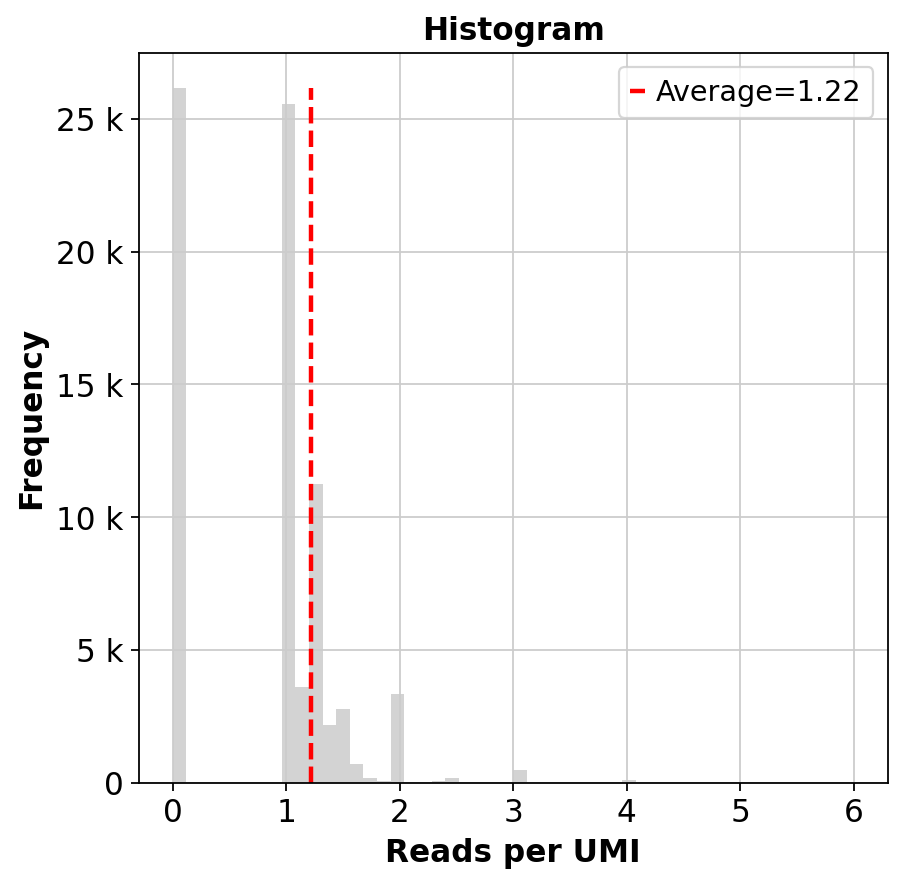

In [56]:
fig, ax = plt.subplots(figsize=(6,6), facecolor="white")

n, bins, _ = ax.hist(reads_per_umi.A1, bins=50, color="lightgray")
ax.vlines(
    x=avg_reads_per_umi,
    ymin=0, ymax=np.max(n),
    color="red", linestyle="--", lw=2,
    label=f"Average={avg_reads_per_umi:.2f}"
)

ax.set_xlabel("Reads per UMI", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.yaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
ax.set_title("Histogram", fontweight="bold")
ax.legend()

plt.show()

## UMI (one vs. rest)

- Ideally, the winning one shouldn't be winning by having less than e.g. 10 UMIs?
- Ideally, the losing ones should have UMIs close to zero.

### All

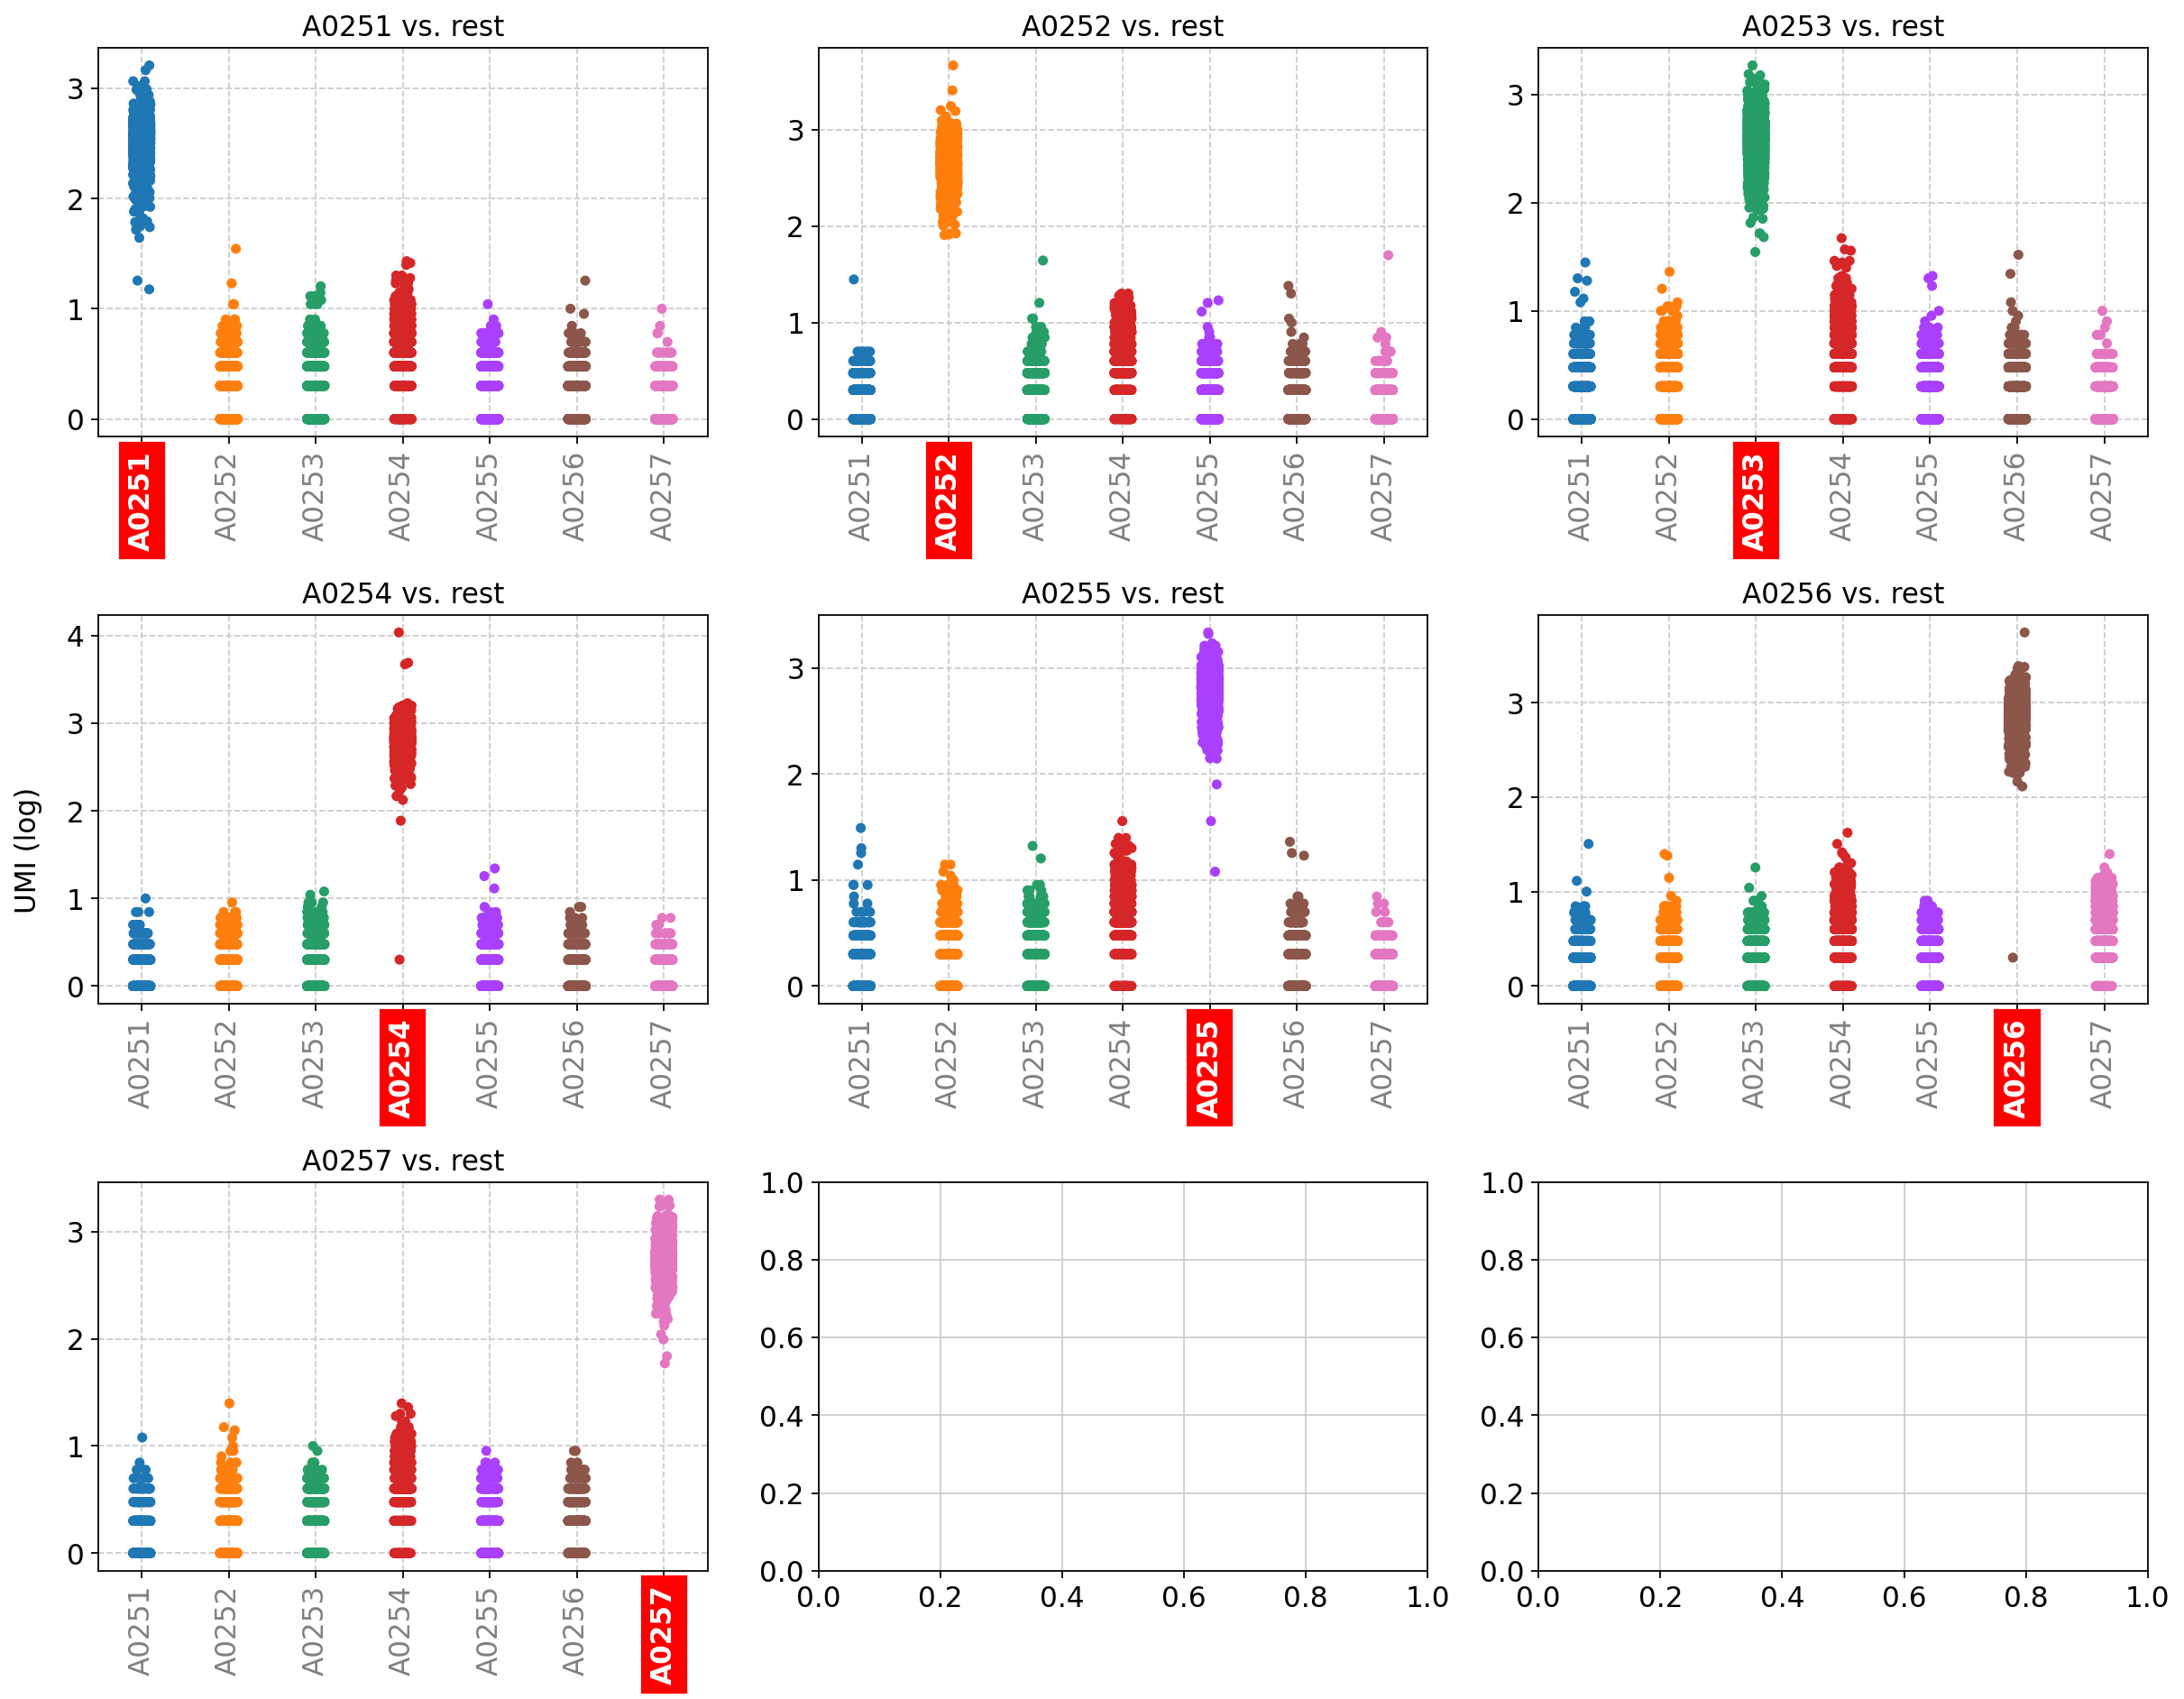

In [57]:
num_hashtags = len(adata.var_names)
num_cols = 3
num_rows = math.ceil(num_hashtags / num_cols)

fig, axes = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(15, num_rows * 4), facecolor="white")
axes = np.ravel(axes)

for idx, hashtag in enumerate(sorted(hashtags)):

    ax = axes[idx]

    df_tmp = adata[adata.obs["hash_id"] == hashtag].to_df()
    df_tmp.columns = df_tmp.columns.str.split("-").str[0]

    sns.stripplot(data=np.log10(df_tmp + 1), ax=ax)

    ax.set_title(f"{hashtag} vs. rest")
    ax.grid(b=True, linestyle="--")
    ax.tick_params(axis="x", rotation=90)

    for tick in ax.xaxis.get_major_ticks():
        if tick.label.get_text() == hashtag:
            tick.label.set_color("white")
            tick.label.set_fontweight("heavy")
            tick.label.set_backgroundcolor("red")
        else:
            tick.label.set_color("gray")

fig.text(-0.01, 0.5, "UMI (log)", va='center', rotation='vertical')
plt.tight_layout()
plt.show()

### 25th Percentile

In [58]:
umi_sum_percentile_25 = adata.obs["total_umis"].describe()["25%"]
umi_sum_percentile_25

372.0

In [59]:
adata[ (adata.obs["total_umis"] < umi_sum_percentile_25) & (adata.obs["hash_id"] != "Doublet") ].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
227434332055453,0,0,0,1,0,235,1
170678352992099,245,0,0,3,0,0,0
240695043382683,361,1,2,0,0,0,0
236845410696028,1,0,340,4,2,1,1
195418285102812,0,0,265,0,5,0,1
...,...,...,...,...,...,...,...
230748973090652,336,2,3,1,1,2,0
239458986089772,0,1,352,3,0,0,0
157604587195227,234,1,12,11,0,0,0
205861516597556,324,4,2,4,0,0,0


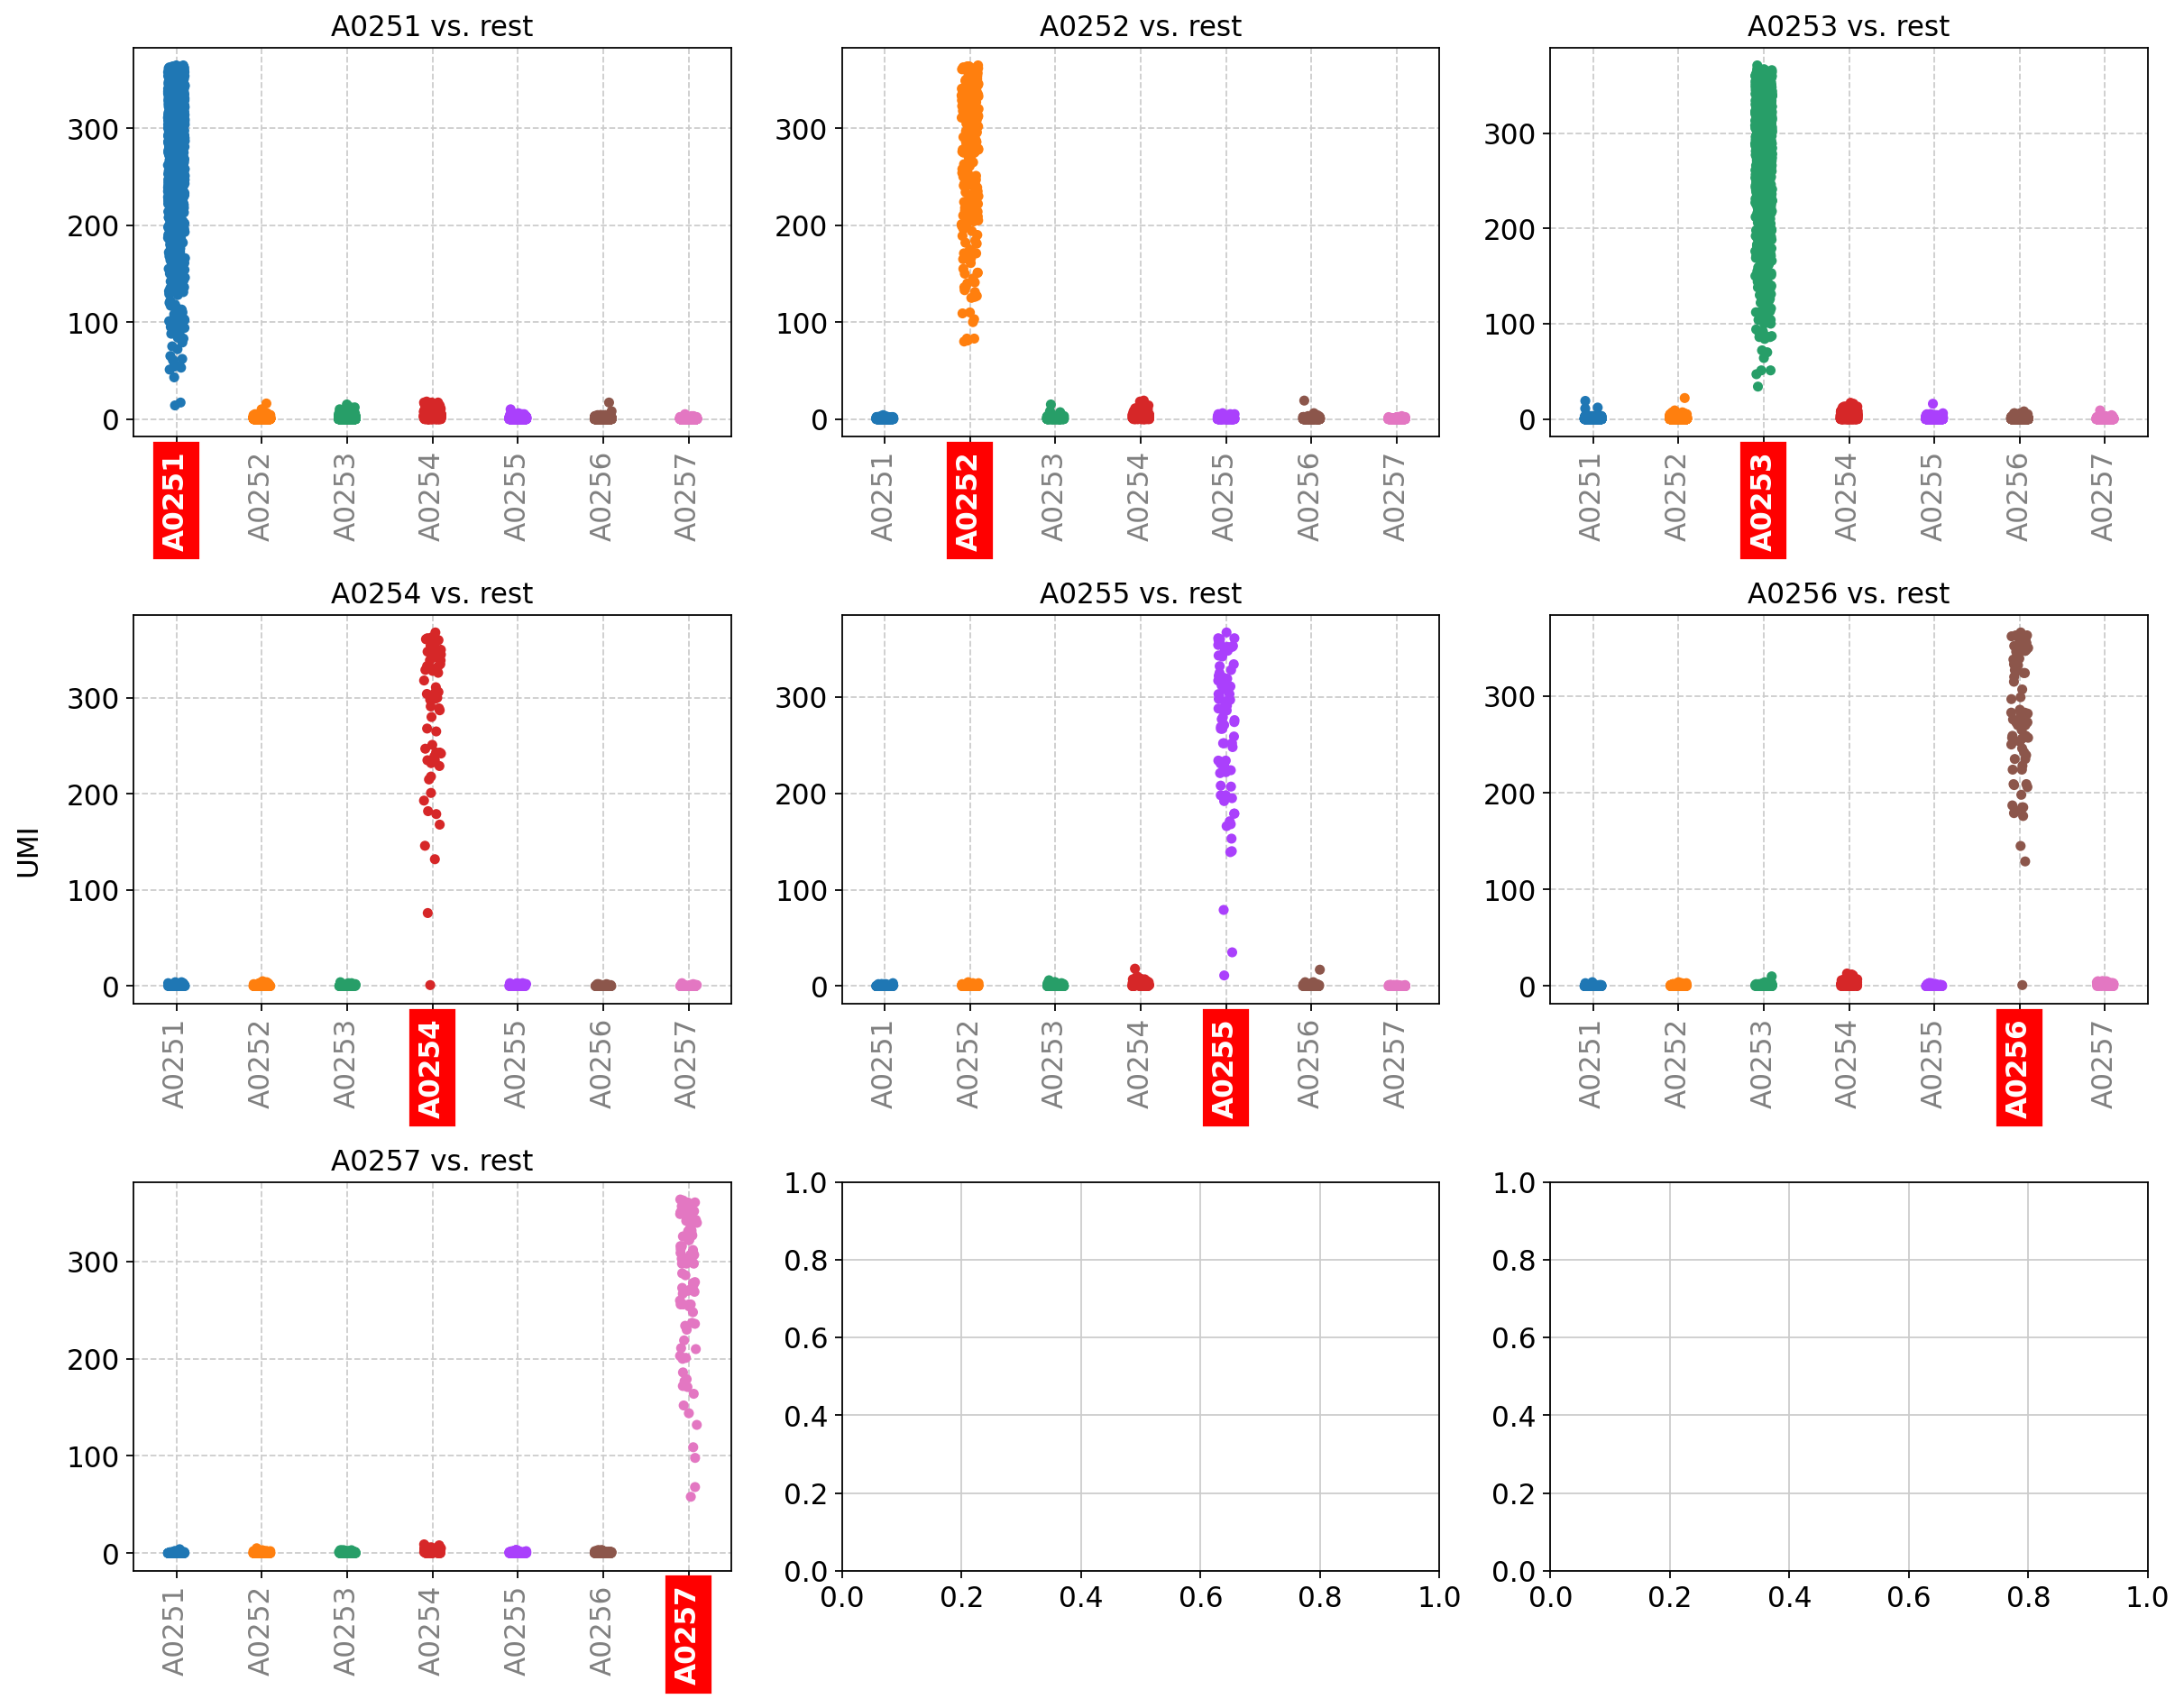

In [60]:
num_hashtags = len(adata.var_names)
num_cols = 3
num_rows = math.ceil(num_hashtags / num_cols)

fig, axes = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(15, num_rows * 4), facecolor="white")
axes = np.ravel(axes)

for idx, hashtag in enumerate(sorted(hashtags)):

    ax = axes[idx]

    df_tmp = adata[ (adata.obs["total_umis"] < umi_sum_percentile_25) & (adata.obs["hash_id"] == hashtag) ].to_df()
    df_tmp.columns = df_tmp.columns.str.split("-").str[0]

    sns.stripplot(data=df_tmp, ax=ax)

    ax.set_title(f"{hashtag} vs. rest")
    ax.grid(b=True, linestyle="--")
    ax.tick_params(axis="x", rotation=90)

    for tick in ax.xaxis.get_major_ticks():
        if tick.label.get_text() == hashtag:
            tick.label.set_color("white")
            tick.label.set_fontweight("heavy")
            tick.label.set_backgroundcolor("red")
        else:
            tick.label.set_color("gray")

fig.text(-0.01, 0.5, "UMI", va='center', rotation='vertical')
plt.tight_layout()
plt.show()

## UMI Distribution

/tmp/ipykernel_755/667289335.py:12: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  ax = fig.add_subplot(num_rows, num_cols, idx_plot)


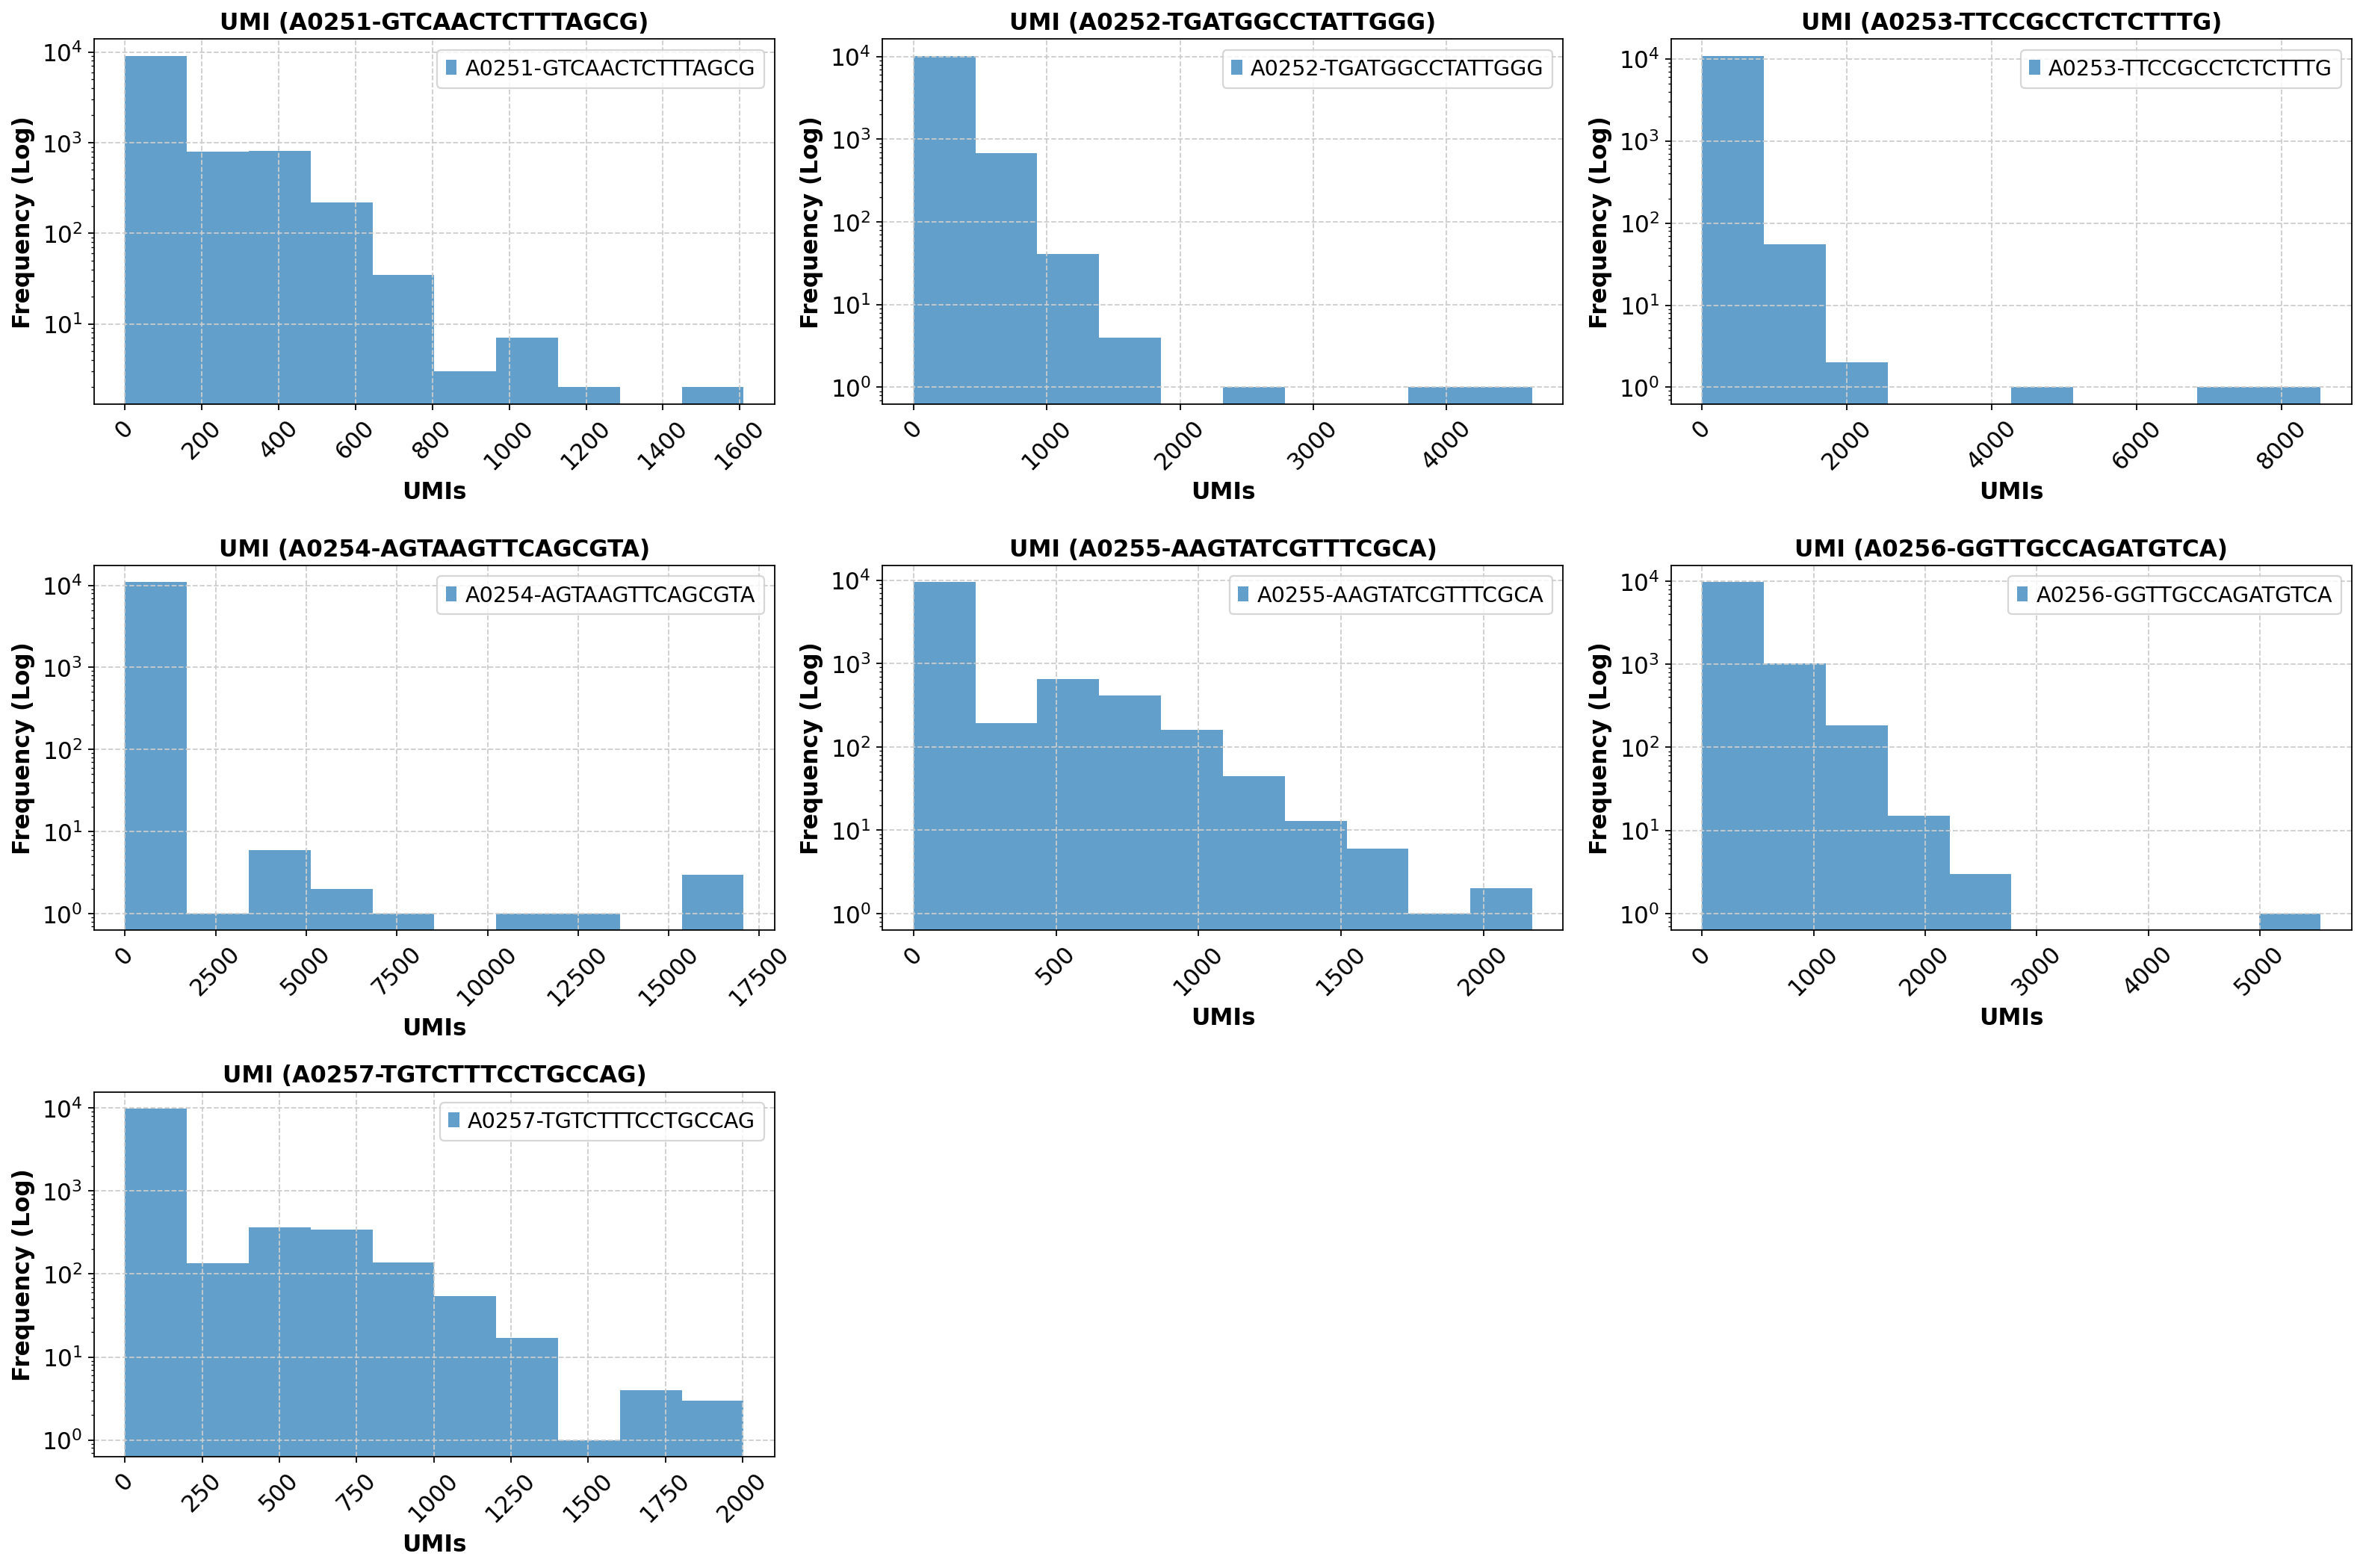

In [ ]:
num_hashtags = len(adata.var_names)
num_cols = 3
num_rows = num_hashtags / num_cols + 1

fig = plt.figure(figsize=(20, num_rows * 4), facecolor="white")

idx_plot = 0

for idx, col in enumerate(adata.var_names):

    idx_plot += 1
    ax = fig.add_subplot(num_rows, num_cols, idx_plot)

    df_tmp = adata[:, idx].to_df().sort_values(by=adata.var_names[idx], ascending=False)

    ax.hist(df_tmp, bins=10, alpha=0.7, label=col)

    ax.set_xlabel("UMIs", fontweight="bold")
    ax.set_ylabel("Frequency (Log)", fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.set_title(f"UMI ({col})", fontweight="bold")
    ax.grid(b=True, linestyle="--")
    ax.set_yscale("log")
    ax.legend()

plt.tight_layout()
plt.show()

## Negative Check

In [62]:
# sort by total umi in descending order
adata_sorted = adata[adata.obs.sort_values(by="total_umis", ascending=False).index]

In [63]:
adata_sorted.to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
126268612721964,1,0,1,17070,8,5,1014
231754935421741,2,7,4,15648,13,1233,834
120703436111133,0,503,1,15721,11,2,1
195554937355164,0,450,0,12533,4,682,904
134585729570651,0,0,1,10850,7,4,0
...,...,...,...,...,...,...,...
230677806501099,0,0,0,0,0,0,0
125238491630507,0,0,0,0,0,0,0
134513488743659,0,0,0,0,0,0,0
239460343532779,0,0,0,0,0,0,0


### Zero Rows

In [64]:
adata_sorted[ adata_sorted.obs["total_umis"] == 0 ].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
235214378491291,0,0,0,0,0,0,0
125238492219116,0,0,0,0,0,0,0
125238491855662,0,0,0,0,0,0,0
239406522223851,0,0,0,0,0,0,0
230677806501099,0,0,0,0,0,0,0
125238491630507,0,0,0,0,0,0,0
134513488743659,0,0,0,0,0,0,0
239460343532779,0,0,0,0,0,0,0
125238491662763,0,0,0,0,0,0,0


In [65]:
adata_sorted[ adata_sorted.obs["total_umis"] == 0 ].shape

(9, 7)

In [66]:
# percentage
np.count_nonzero(adata_sorted.obs["total_umis"] == 0) / adata_sorted.shape[0] * 100.0

0.08213927169845761

### Singlets

In [67]:
mask_singlet = (adata_sorted.obs["hash_id"] != "Doublet") & (adata_sorted.obs["hash_id"] != "Negative")
mask_singlet

126268612721964    False
231754935421741    False
120703436111133    False
195554937355164    False
134585729570651     True
                   ...  
230677806501099    False
125238491630507    False
134513488743659    False
239460343532779    False
125238491662763    False
Name: hash_id, Length: 10957, dtype: bool

In [68]:
adata_sorted[mask_singlet]

View of AnnData object with n_obs × n_vars = 9935 × 7
    obs: 'unmapped', 'barcode_sequence', 'hash_id', 'unmapped_reads', 'total_reads', 'total_umis'
    var: 'feature_name', 'total_reads'
    layers: 'reads'

In [69]:
adata_sorted[mask_singlet].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
134585729570651,0,0,1,10850,7,4,0
125257194105635,0,1,3,2,2,5546,24
157131055163165,0,1,2,4886,5,2,4
200982521593251,4,1,0,4691,4,0,0
191164522057004,1,4642,0,4,1,0,0
...,...,...,...,...,...,...,...
204908283221805,17,0,1,3,0,0,0
231282308437941,14,0,0,2,0,1,0
126682835925812,0,0,0,0,11,0,0
122490786564902,0,0,0,0,0,1,0


In [70]:
# singlet only, total_umis < 10
adata_sorted[mask_singlet & (adata_sorted.obs["total_umis"] < 10)].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
122490786564902,0,0,0,0,0,1,0
199807070756251,0,0,0,1,0,0,0


In [71]:
# singlet only, total_umis >= 10
adata_sorted[mask_singlet & (adata_sorted.obs["total_umis"] >= 10)].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
134585729570651,0,0,1,10850,7,4,0
125257194105635,0,1,3,2,2,5546,24
157131055163165,0,1,2,4886,5,2,4
200982521593251,4,1,0,4691,4,0,0
191164522057004,1,4642,0,4,1,0,0
...,...,...,...,...,...,...,...
122436428123060,0,1,34,1,0,0,0
226212233211229,0,0,0,0,35,0,0
204908283221805,17,0,1,3,0,0,0
231282308437941,14,0,0,2,0,1,0


### Doublets

In [72]:
mask_doublet = adata_sorted.obs["hash_id"] == "Doublet"
mask_doublet

126268612721964     True
231754935421741     True
120703436111133     True
195554937355164     True
134585729570651    False
                   ...  
230677806501099     True
125238491630507     True
134513488743659     True
239460343532779     True
125238491662763     True
Name: hash_id, Length: 10957, dtype: bool

In [73]:
adata_sorted[mask_doublet].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
126268612721964,1,0,1,17070,8,5,1014
231754935421741,2,7,4,15648,13,1233,834
120703436111133,0,503,1,15721,11,2,1
195554937355164,0,450,0,12533,4,682,904
232250179700469,337,2,8536,4,553,0,0
...,...,...,...,...,...,...,...
230677806501099,0,0,0,0,0,0,0
125238491630507,0,0,0,0,0,0,0
134513488743659,0,0,0,0,0,0,0
239460343532779,0,0,0,0,0,0,0


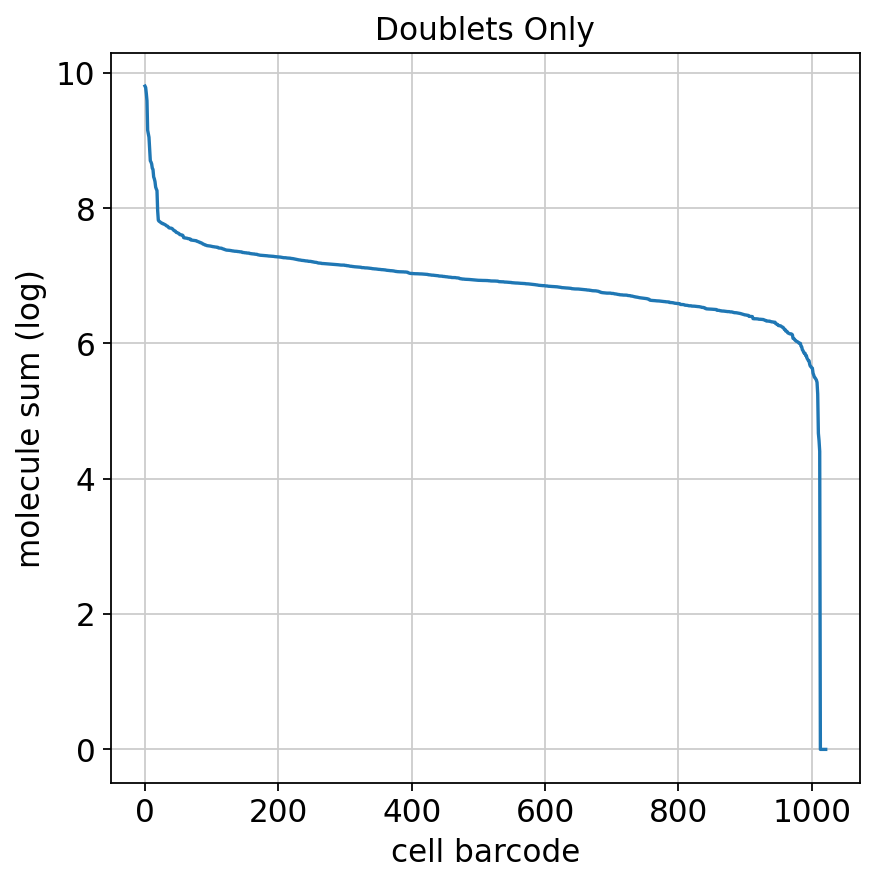

In [74]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

ax.plot(
    range(0, adata_sorted[mask_doublet].shape[0]),
    np.log(adata_sorted[mask_doublet].obs["total_umis"] + 1)
)
ax.set_ylabel("molecule sum (log)")
ax.set_xlabel("cell barcode")
ax.set_title("Doublets Only")

plt.show()

In [75]:
# doublet only, total_umis < 10
adata_sorted[mask_doublet & (adata_sorted.obs["total_umis"] < 10)].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
235214378491291,0,0,0,0,0,0,0
125238492219116,0,0,0,0,0,0,0
125238491855662,0,0,0,0,0,0,0
239406522223851,0,0,0,0,0,0,0
230677806501099,0,0,0,0,0,0,0
125238491630507,0,0,0,0,0,0,0
134513488743659,0,0,0,0,0,0,0
239460343532779,0,0,0,0,0,0,0
125238491662763,0,0,0,0,0,0,0


In [76]:
# doublet only, total_umis >= 10
adata_sorted[mask_doublet & (adata_sorted.obs["total_umis"] >= 10)].to_df()

,A0251-GTCAACTCTTTAGCG,A0252-TGATGGCCTATTGGG,A0253-TTCCGCCTCTCTTTG,A0254-AGTAAGTTCAGCGTA,A0255-AAGTATCGTTTCGCA,A0256-GGTTGCCAGATGTCA,A0257-TGTCTTTCCTGCCAG
126268612721964,1,0,1,17070,8,5,1014
231754935421741,2,7,4,15648,13,1233,834
120703436111133,0,503,1,15721,11,2,1
195554937355164,0,450,0,12533,4,682,904
232250179700469,337,2,8536,4,553,0,0
...,...,...,...,...,...,...,...
230612561749803,47,57,1,2,32,87,0
191148403341621,0,0,100,0,0,90,0
161409007729565,12,28,1,4,16,45,0
197211702122331,0,0,61,33,1,0,0


## Max vs. Rest Sum

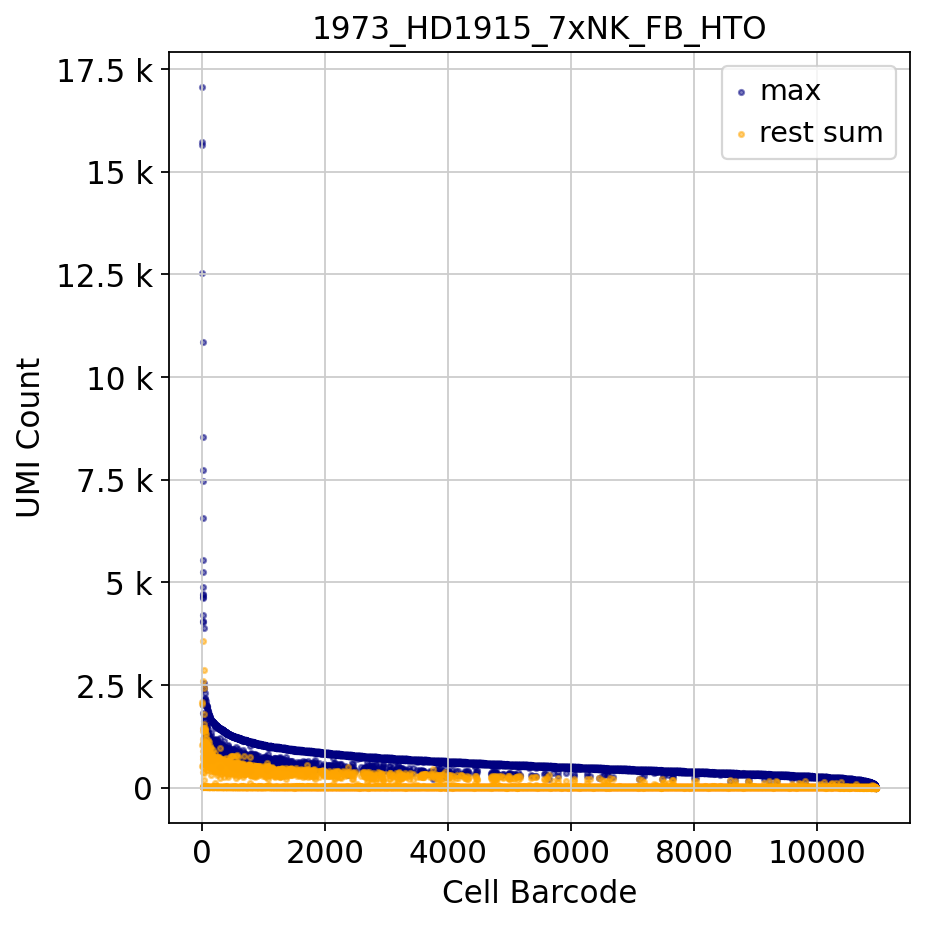

In [77]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

df_sorted = pd.DataFrame(
    np.vstack(adata_sorted.to_df().apply(
        lambda row: sorted(row, reverse=True), axis=1)
    ),
    index=adata.obs_names
)
dfx = df_sorted.copy()
dfx = dfx.assign(rest=df_sorted.iloc[:, 1:].sum(axis=1))
dfx = dfx.assign(maxx=df_sorted.max(axis=1))

ax.scatter(
    range(len(dfx)),
    dfx.maxx,
    c="navy", s=5, alpha=0.5, label="max"
)
ax.scatter(
    range(len(dfx)), dfx.rest,
    c="orange", s=5, alpha=0.5, label="rest sum"
)
ax.set_xlabel("Cell Barcode")
ax.set_ylabel("UMI Count")
ax.yaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
ax.legend()
ax.set_title(sample_name)

plt.tight_layout()
plt.show()

## UMAP

In [78]:
def clr_normalize_each_cell(adata, inplace=True):
    """Normalize count vector for each cell, i.e. for each row of .X"""

    import numpy as np
    import scipy

    def seurat_clr(x):
        # TODO: support sparseness
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x))
        return np.log1p(x / exp)

    if not inplace:
        adata = adata.copy()

    # apply to dense or sparse matrix, along axis. returns dense matrix
    adata.X = np.apply_along_axis(
        seurat_clr, 1, (adata.X.A if scipy.sparse.issparse(adata.X) else adata.X)
    )
    return adata

In [79]:
adata.raw = adata

In [80]:
clr_normalize_each_cell(adata)

AnnData object with n_obs × n_vars = 10957 × 7
    obs: 'unmapped', 'barcode_sequence', 'hash_id', 'unmapped_reads', 'total_reads', 'total_umis'
    var: 'feature_name', 'total_reads'
    layers: 'reads'

In [81]:
sc.pp.log1p(adata)

In [82]:
sc.pp.neighbors(adata)

computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)


In [83]:
sc.tl.leiden(adata, resolution=0.05, random_state=42)

running Leiden clustering
    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


In [84]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


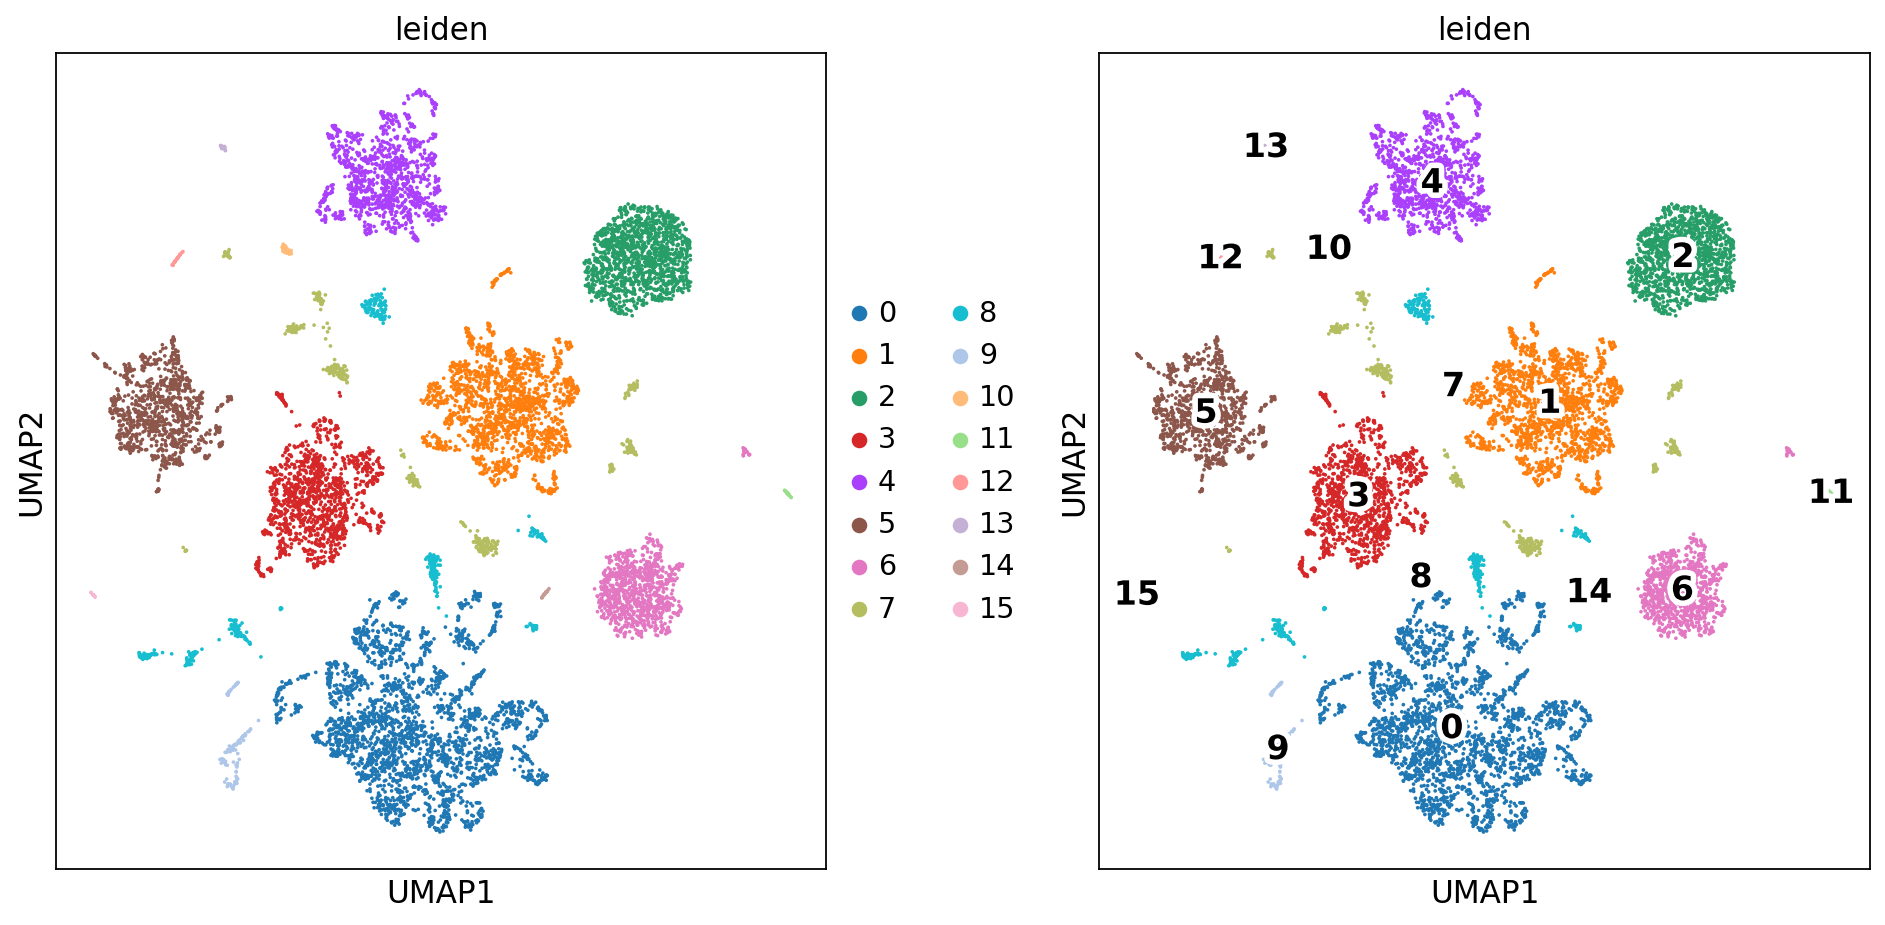

In [85]:
fig, axs = plt.subplots(ncols=2, figsize=(12,6))

sc.pl.umap(
    adata,
    color=["leiden"],
    ax=axs[0], show=False
)

sc.pl.umap(
    adata,
    color=["leiden"],
    legend_loc="on data",
    legend_fontsize=15,
    legend_fontoutline=5,
    ax=axs[1], show=False
)

plt.tight_layout()
plt.show()

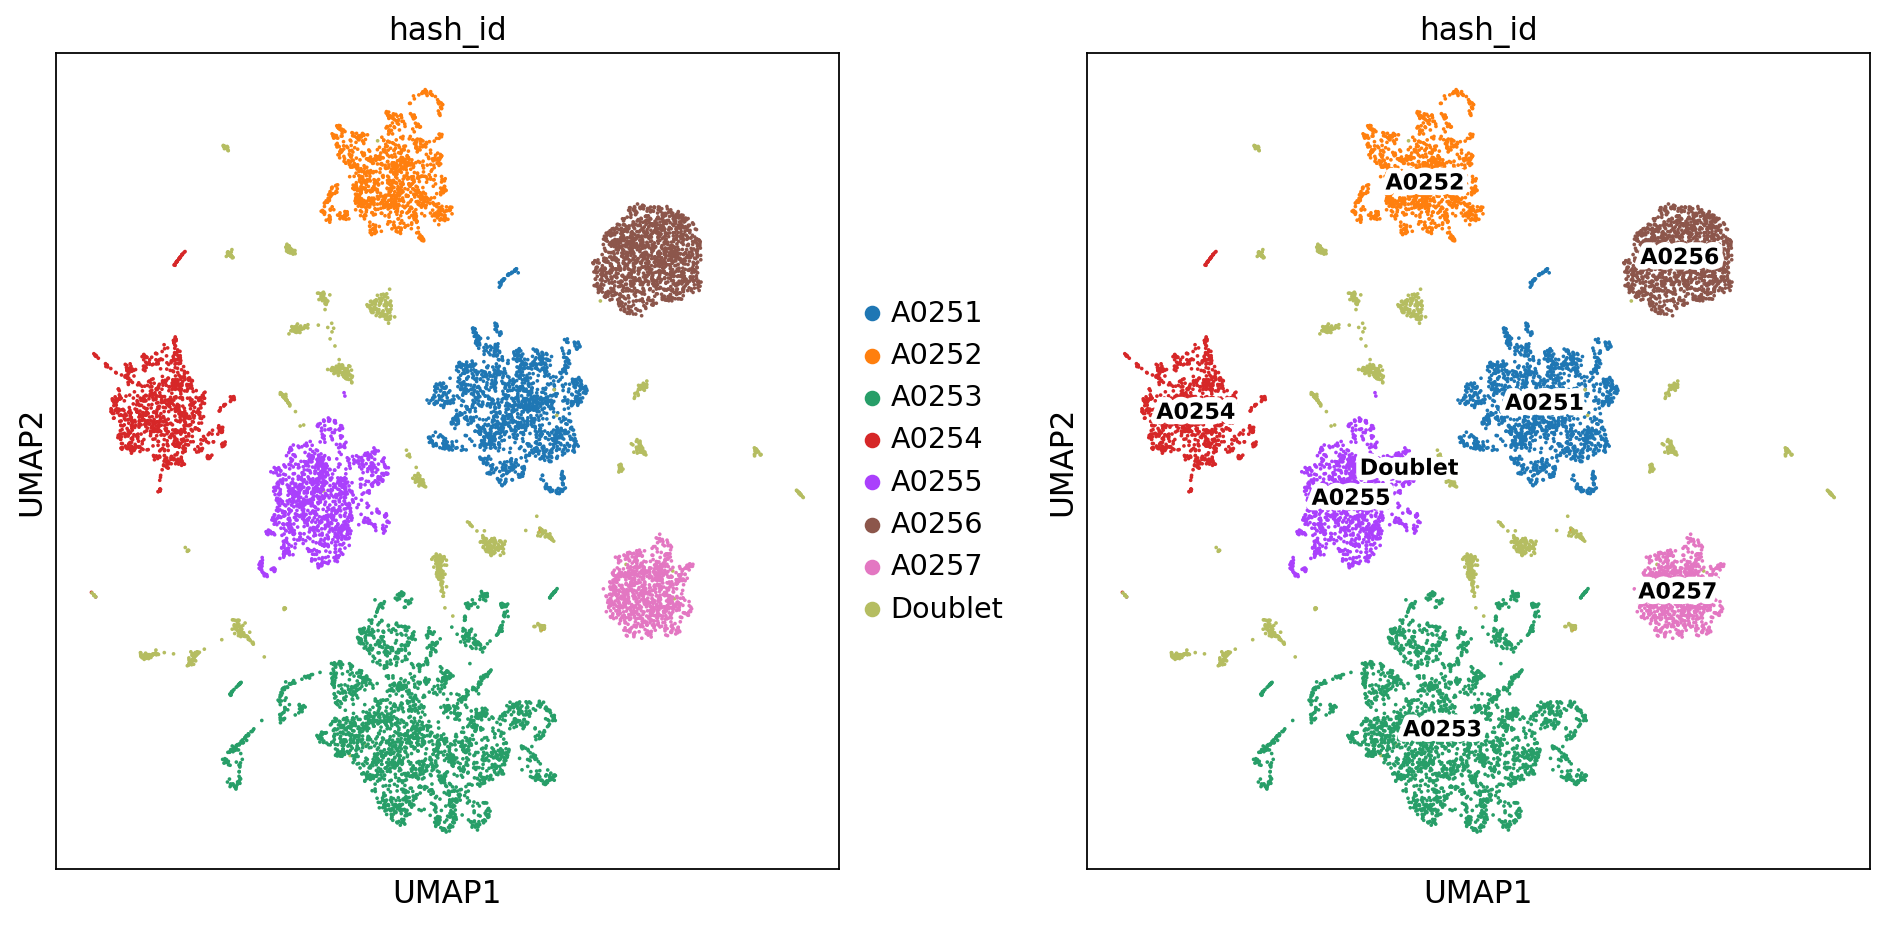

In [86]:
fig, axs = plt.subplots(ncols=2, figsize=(12,6))

sc.pl.umap(
    adata,
    color=["hash_id"],
    ax=axs[0], show=False
)

sc.pl.umap(
    adata,
    color=["hash_id"],
    legend_loc="on data",
    legend_fontsize=10,
    legend_fontoutline=5,
    ax=axs[1], show=False
)

plt.tight_layout()
plt.show()

In [87]:
from matplotlib.colors import ListedColormap

my_cmap1 = ListedColormap(sns.color_palette("Blues").as_hex())
my_cmap2 = sns.color_palette("Paired").as_hex()
my_cmap2[0] = "lightgray"
my_cmap2 = ListedColormap(my_cmap2)

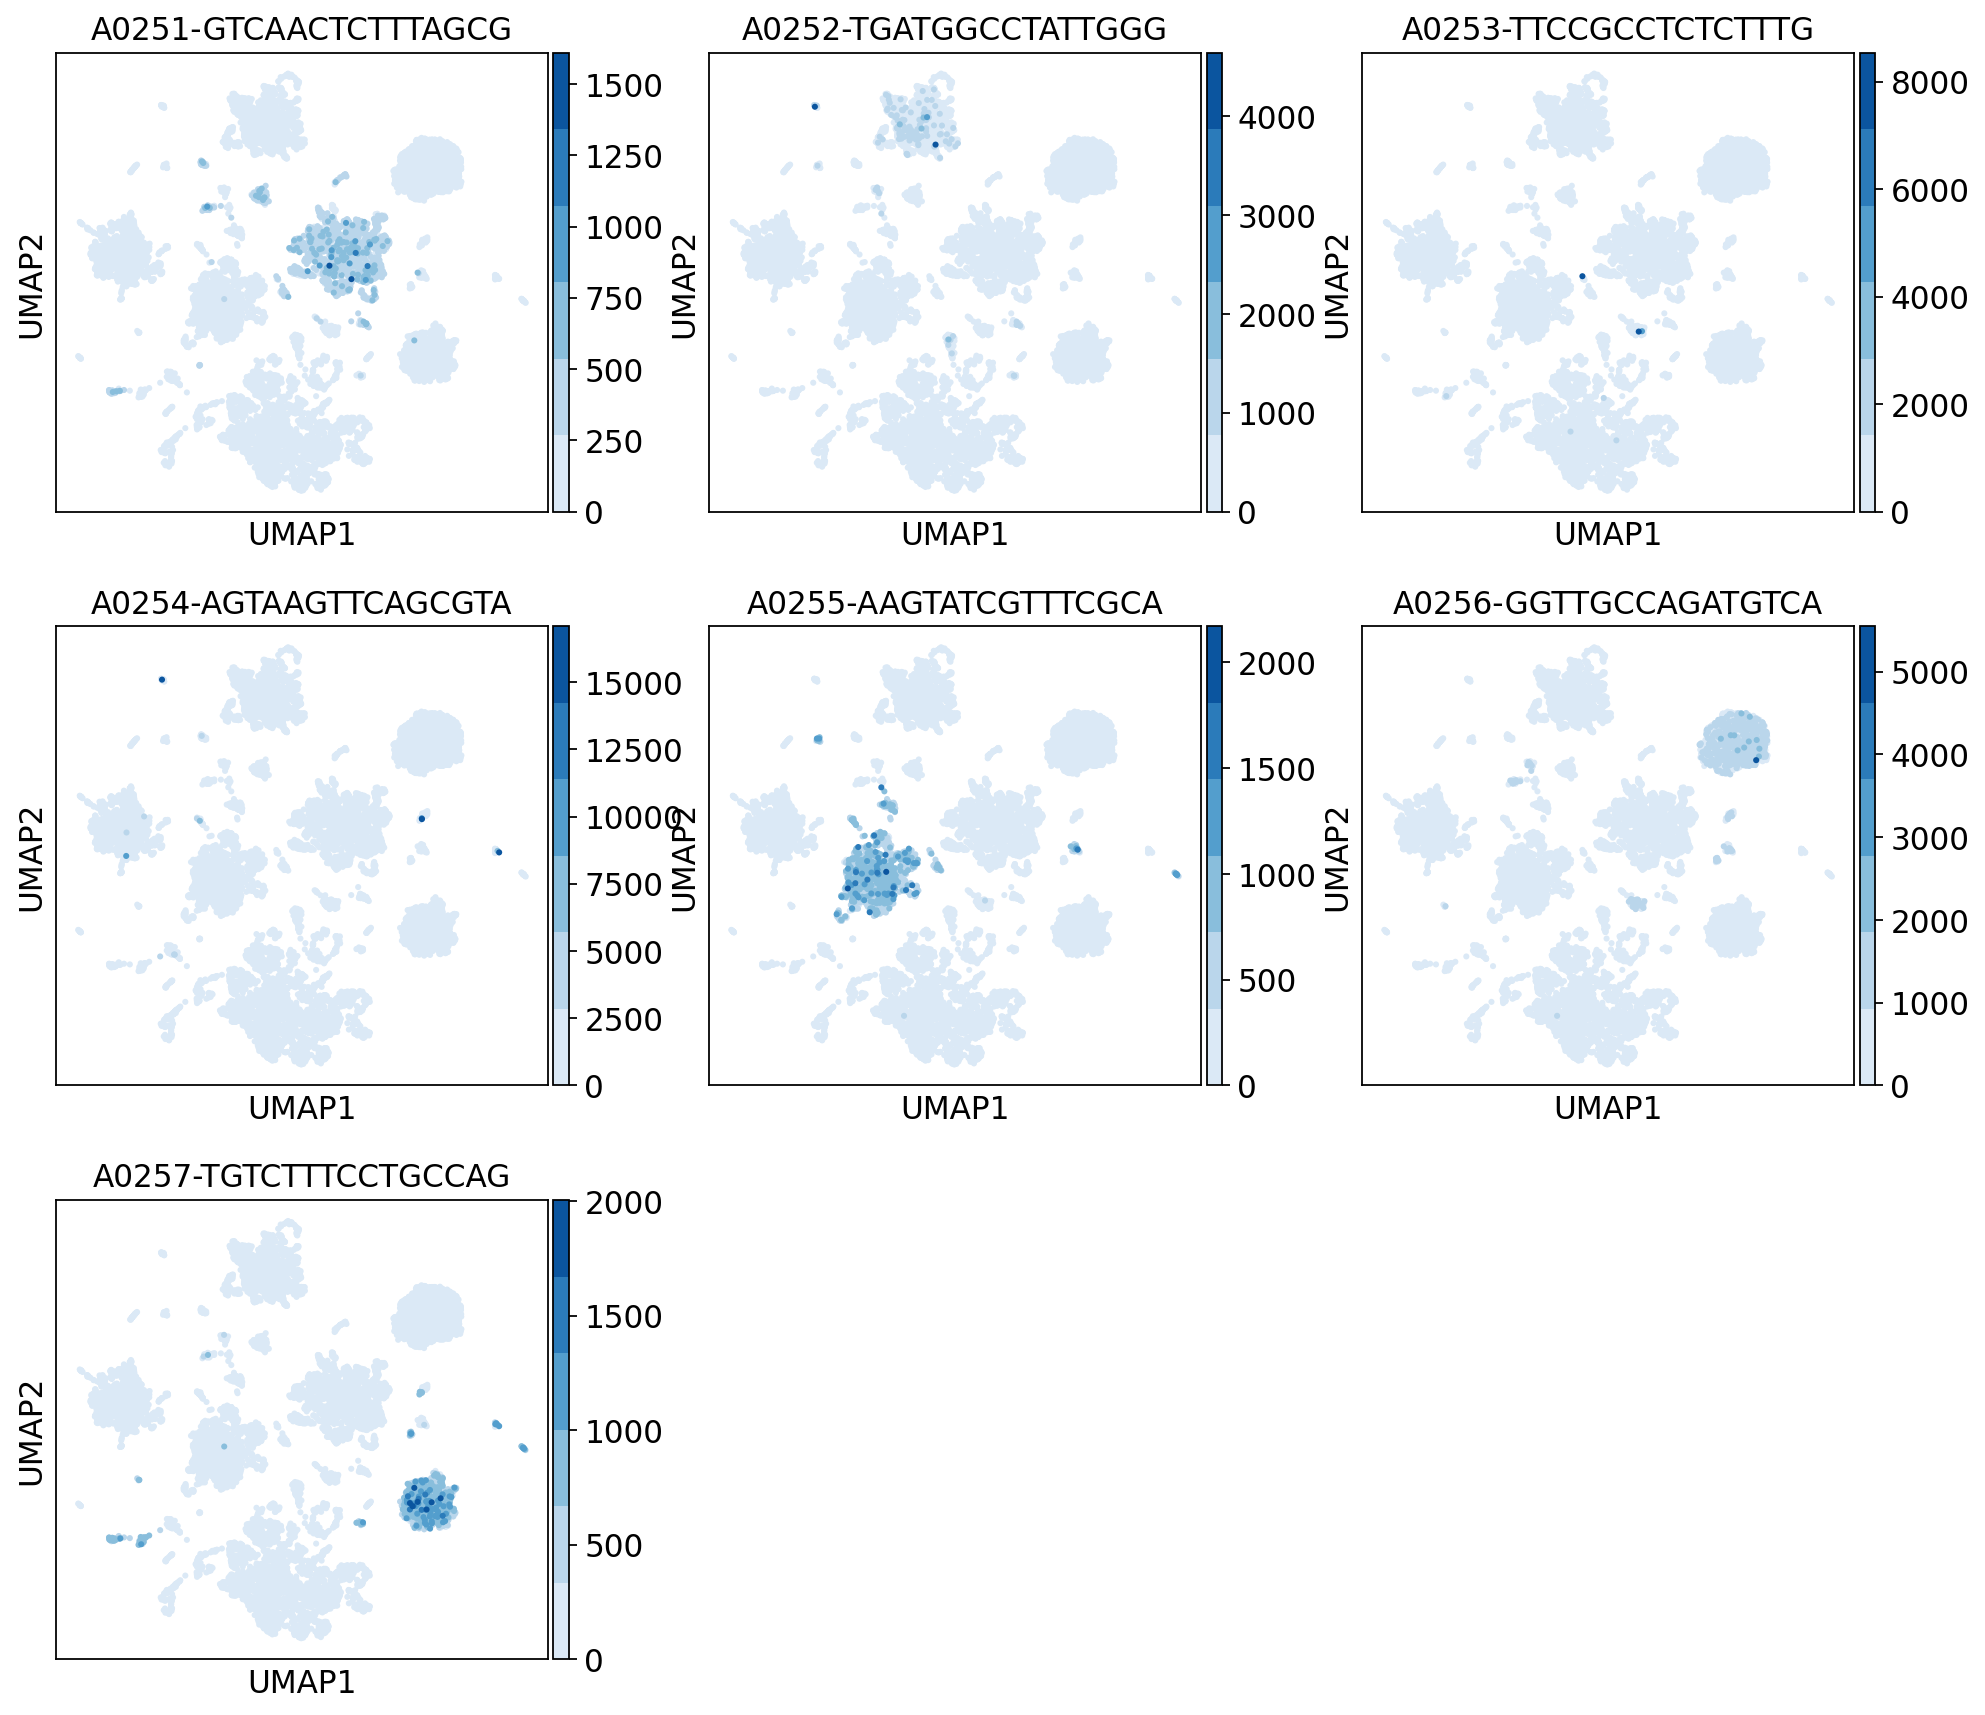

In [88]:
sc.pl.umap(
    adata,
    color=adata.var_names,
    color_map=my_cmap1,
    size=30,
    ncols=3,
)

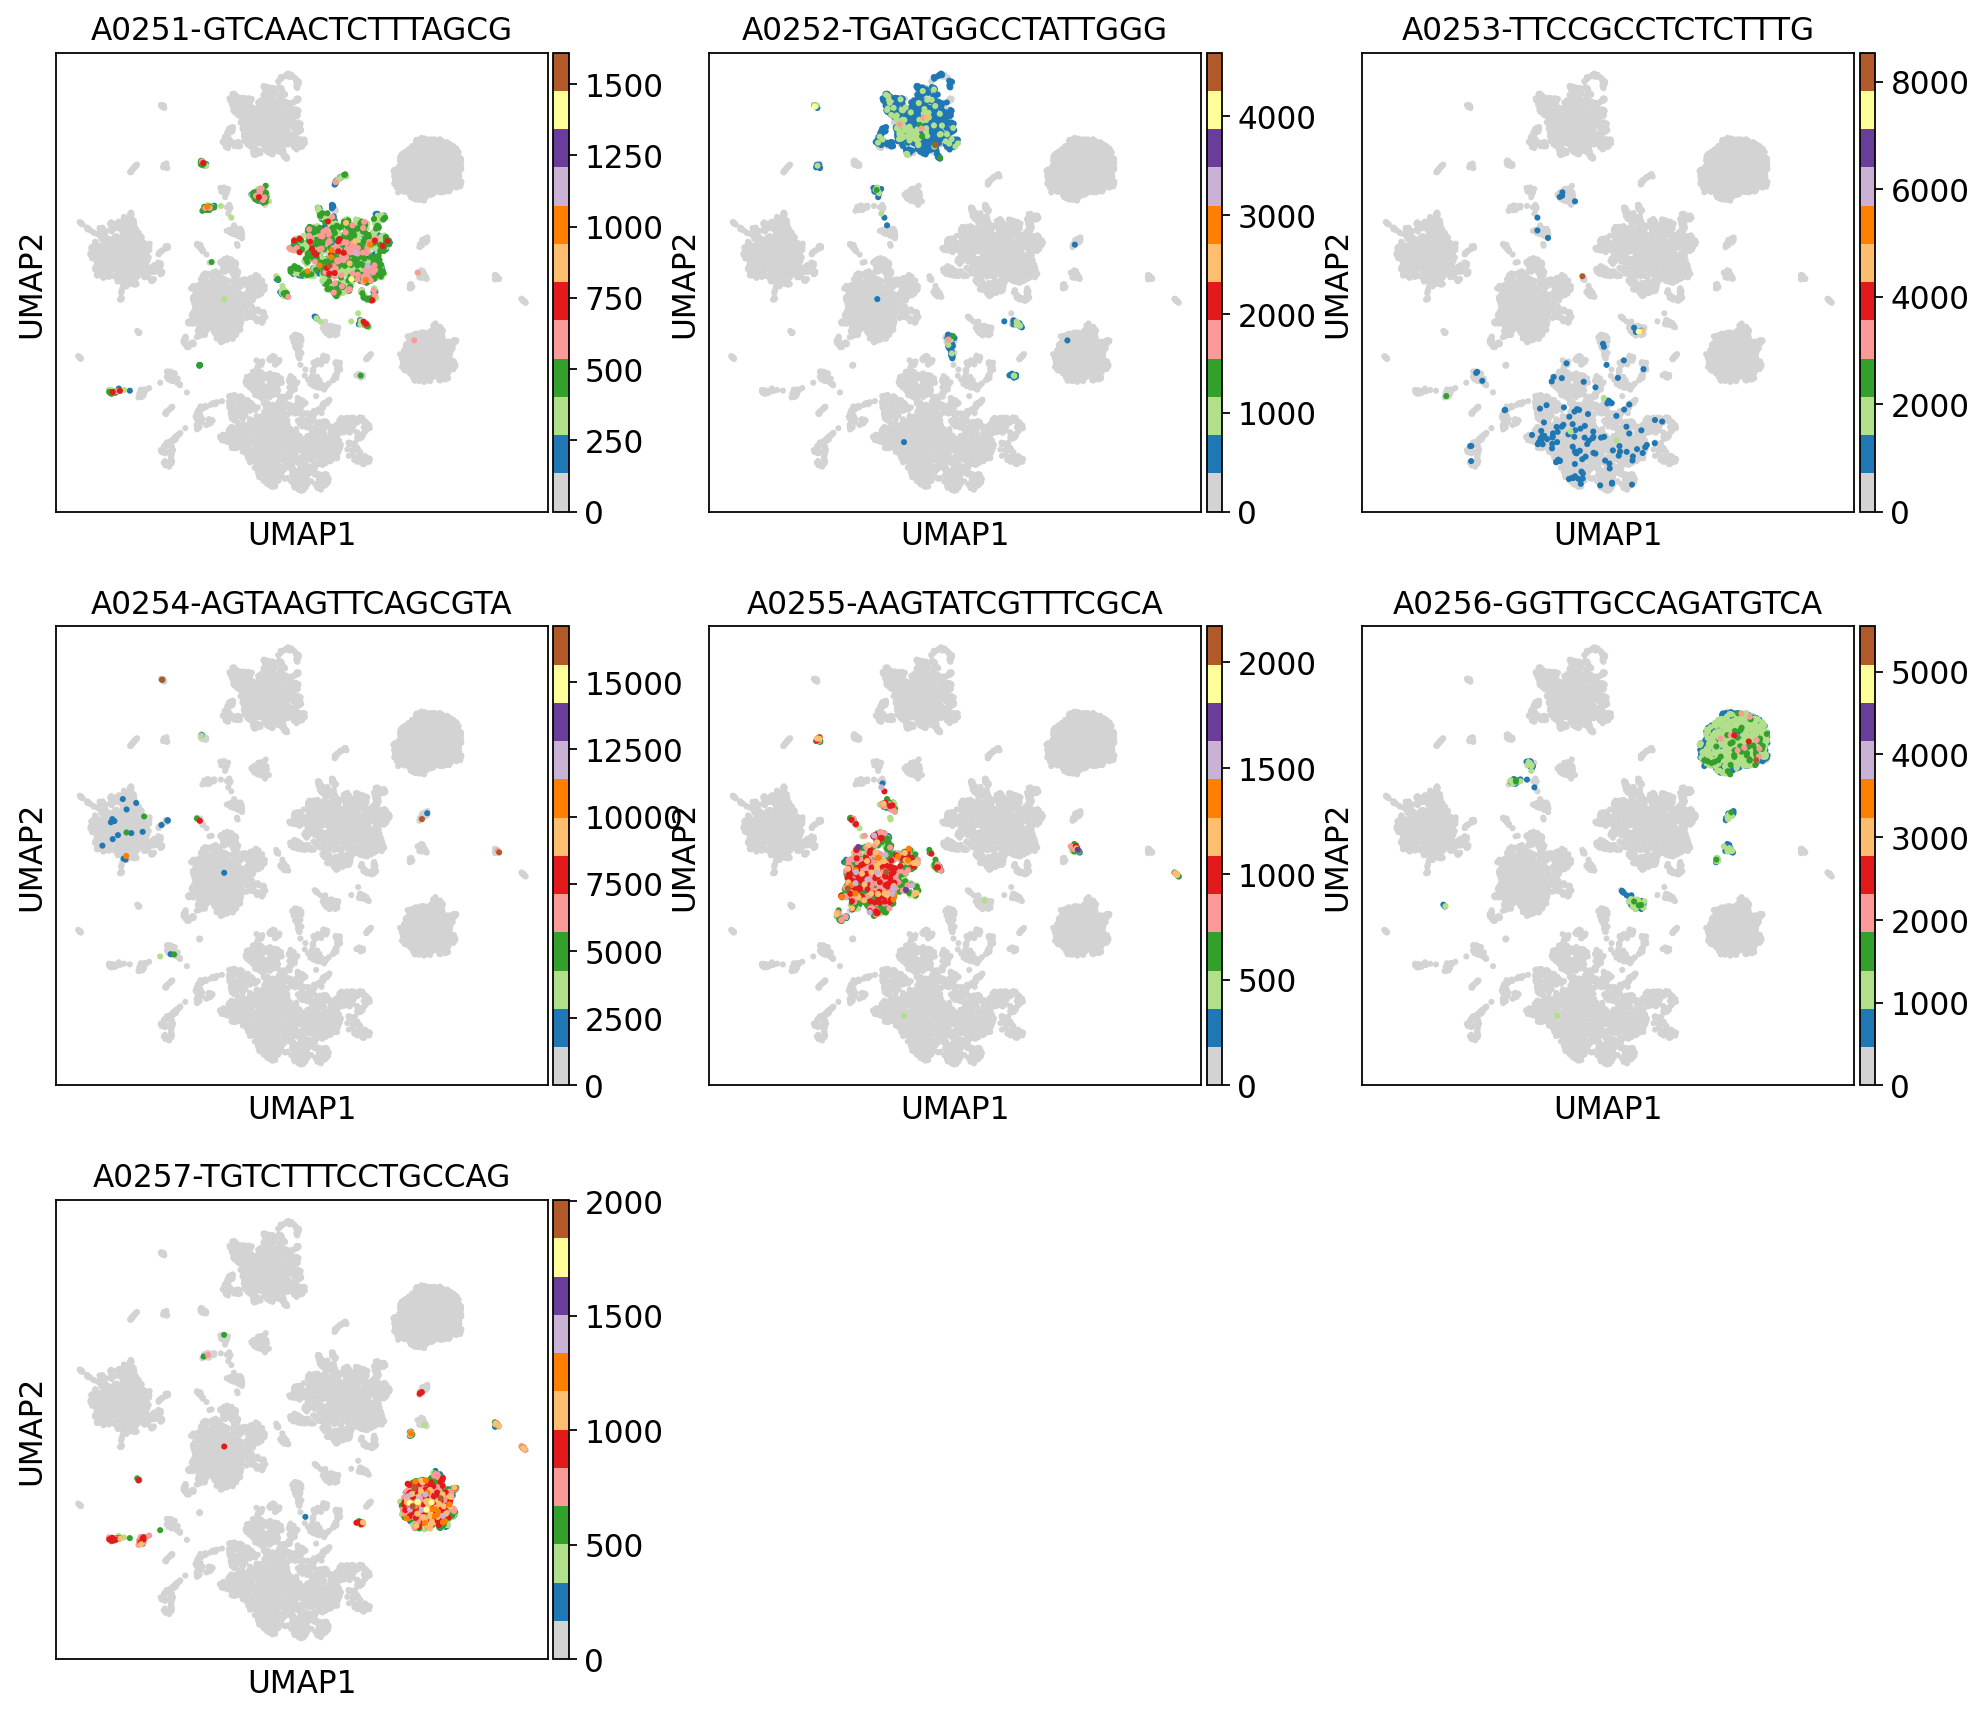

In [89]:
sc.pl.umap(
    adata,
    color=adata.var_names,
    color_map=my_cmap2,
    size=30,
    ncols=3,
)

## Write adata to Disk

In [90]:
adata

AnnData object with n_obs × n_vars = 10957 × 7
    obs: 'unmapped', 'barcode_sequence', 'hash_id', 'unmapped_reads', 'total_reads', 'total_umis', 'leiden'
    var: 'feature_name', 'total_reads'
    uns: 'log1p', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'hash_id_colors'
    obsm: 'X_umap'
    layers: 'reads'
    obsp: 'distances', 'connectivities'

In [91]:
adata.write(os.path.join(path_outdir, f"{sample_name}.QC.h5ad"))